**Category 1 - Lasso Regression**

Demonstration of Lasso regression applied to cross-sectional equity return prediction using simulated factor data with illustration of regularisation path analysis, cross-validated lambda selection, and sparse factor identification.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker

from sklearn.cluster import KMeans
from sklearn.linear_model import Lasso, LassoCV, lasso_path
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression

from sklearn.neural_network import MLPRegressor
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression

from sklearn.svm import SVC
from sklearn.datasets import make_classification
from sklearn.model_selection import validation_curve

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold
from sklearn.decomposition import PCA

from sklearn.metrics import r2_score, mean_squared_error
from sklearn.metrics import silhouette_score, silhouette_samples

import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'sans-serif',
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})

print('Libraries loaded successfully.')


Libraries loaded successfully.


**Simulate Factor Data**

Simulation of a cross-sectional dataset of 200 equities with 30 candidate alpha factors (e.g., momentum, value, quality, technical, macro exposures). Only 6 of the 30 factors are truly predictive. LASSO should identify these and shrink the rest to zero.

In [ ]:
# Simulation parameters
n_stocks = 200      # number of equities in cross-section
n_factors = 30      # total candidate alpha factors
n_true = 6          # truly predictive factors
noise_std = 0.03    # idiosyncratic noise (monthly return units)

# Factor names (mix of styles and macro)
factor_names = [
    'Momentum_12M', 'Momentum_3M', 'Value_BtP', 'Value_EtP', 'Quality_ROE',
    'Quality_GP', 'Size_LogMktCap', 'Volatility_252D', 'Beta_60M', 'Liquidity',
    'Leverage', 'EarningsRevision', 'Dividend_Yield', 'EV_EBITDA', 'FCF_Yield',
    'Macro_CPI', 'Macro_PMI', 'Macro_YieldCurve', 'Macro_Credit', 'Macro_DollarIndex',
    'Technical_RSI', 'Technical_MACD', 'Analyst_Coverage', 'Short_Interest',
    'Accruals', 'CapEx_Intensity', 'GrossMargin_Trend', 'Revenue_Surprise',
    'ESG_Score', 'Buyback_Yield'
]

# True signal factors (the 6 we'll embed signal in)
true_factors = ['Momentum_12M', 'Value_BtP', 'Quality_ROE', 'EarningsRevision', 'Revenue_Surprise', 'Short_Interest']
true_betas = [0.08, 0.06, 0.05, 0.07, 0.09, -0.04]  # true regression coefficients

# Simulate factor exposures (standardised)
X_raw = np.random.randn(n_stocks, n_factors)
X_df = pd.DataFrame(X_raw, columns=factor_names)

# Construct returns: signal from 6 true factors + noise
true_idx = [factor_names.index(f) for f in true_factors]
y = X_raw[:, true_idx] @ np.array(true_betas) + np.random.randn(n_stocks) * noise_std

print(f'Dataset: {n_stocks} stocks × {n_factors} factors')
print(f'True predictive factors: {true_factors}')
print(f'True coefficients:       {true_betas}')
print(f'\nForward return summary:')
print(pd.Series(y, name='1M Return').describe().round(4))

Dataset: 200 stocks × 30 factors
True predictive factors: ['Momentum_12M', 'Value_BtP', 'Quality_ROE', 'EarningsRevision', 'Revenue_Surprise', 'Short_Interest']
True coefficients:       [0.08, 0.06, 0.05, 0.07, 0.09, -0.04]

Forward return summary:
count    200.0000
mean      -0.0098
std        0.1736
min       -0.6512
25%       -0.1147
50%       -0.0254
75%        0.1046
max        0.5604
Name: 1M Return, dtype: float64


**Preprocessing — Standardise Features**

LASSO penalises all coefficients equally via the L1 norm, so features must be on the same scale. We apply `StandardScaler` to ensure fair penalisation.

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_df)

# Confirm scaling
means = X_scaled.mean(axis=0)
stds  = X_scaled.std(axis=0)
print(f'Post-scaling: Mean range [{means.min():.2e}, {means.max():.2e}]')
print(f'Post-scaling: Std  range [{stds.min():.4f}, {stds.max():.4f}]')

Post-scaling: Mean range [-2.92e-16, 1.00e-16]
Post-scaling: Std  range [1.0000, 1.0000]


**LASSO Regularisation Path**

The regularisation path shows how each factor's coefficient evolves as the penalty parameter λ (alpha) increases from near-zero (OLS-like) to large (full shrinkage). Factors that enter the model at small λ are the most important predictors.

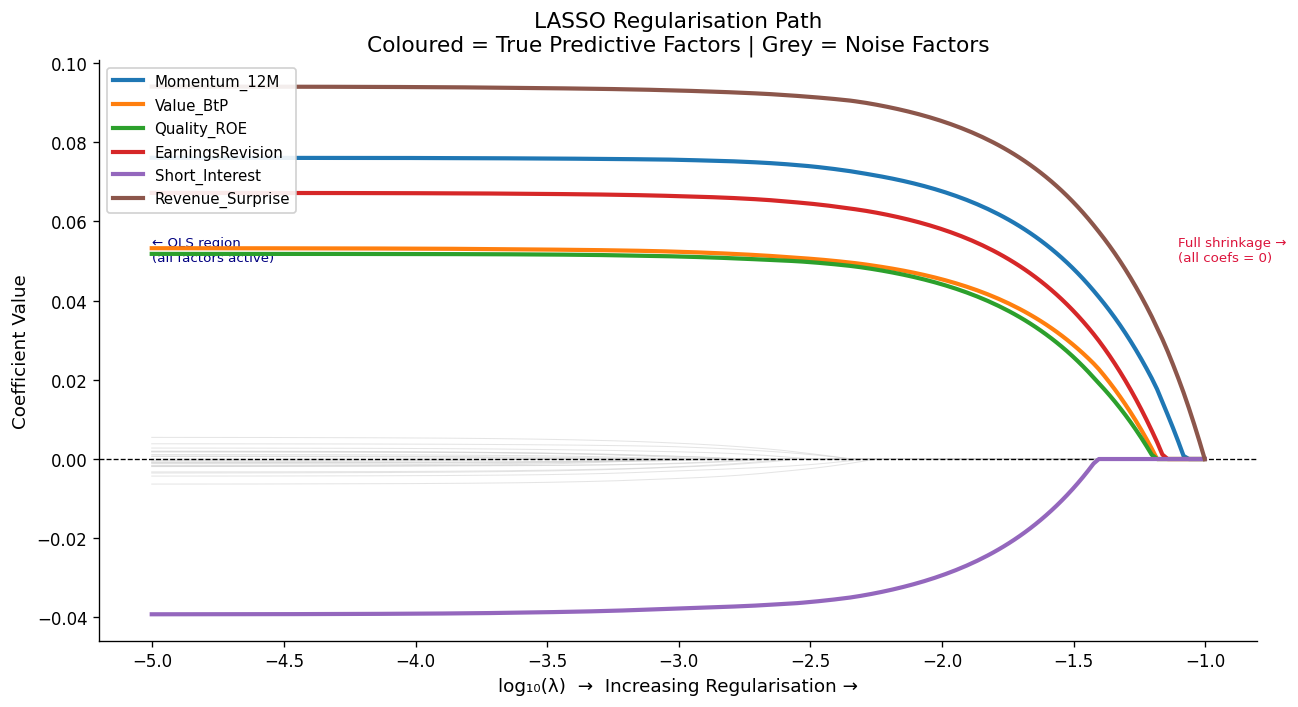

Key observation: True factors enter the model first (at smaller λ). Noise factors remain near zero across the path.


In [ ]:
# Compute LASSO path
alphas, coefs, _ = lasso_path(X_scaled, y, eps=1e-4, n_alphas=200)

fig, ax = plt.subplots(figsize=(11, 6))

# Plot all factor paths (noise factors in light grey)
for i, name in enumerate(factor_names):
    if name in true_factors:
        ax.plot(np.log10(alphas), coefs[i], lw=2.5, label=name, zorder=5)
    else:
        ax.plot(np.log10(alphas), coefs[i], lw=0.6, color='lightgrey', alpha=0.6)

ax.axhline(0, color='black', lw=0.8, linestyle='--')
ax.set_xlabel('log₁₀(λ)  →  Increasing Regularisation →', fontsize=11)
ax.set_ylabel('Coefficient Value', fontsize=11)
ax.set_title('LASSO Regularisation Path\nColoured = True Predictive Factors | Grey = Noise Factors', fontsize=13)
ax.legend(loc='upper left', fontsize=9, framealpha=0.9)
ax.annotate('← OLS region\n(all factors active)', xy=(np.log10(alphas[-1]), 0.05), fontsize=8, color='navy')
ax.annotate('Full shrinkage →\n(all coefs = 0)', xy=(np.log10(alphas[5]), 0.05), fontsize=8, color='crimson')
plt.tight_layout()
plt.show()
print('Key observation: True factors enter the model first (at smaller λ). Noise factors remain near zero across the path.')

**Cross-Validated Lambda Selection**

We use 10-fold cross-validation (`LassoCV`) to identify the optimal λ that minimises out-of-sample MSE.

Optimal λ (alpha): 0.001345


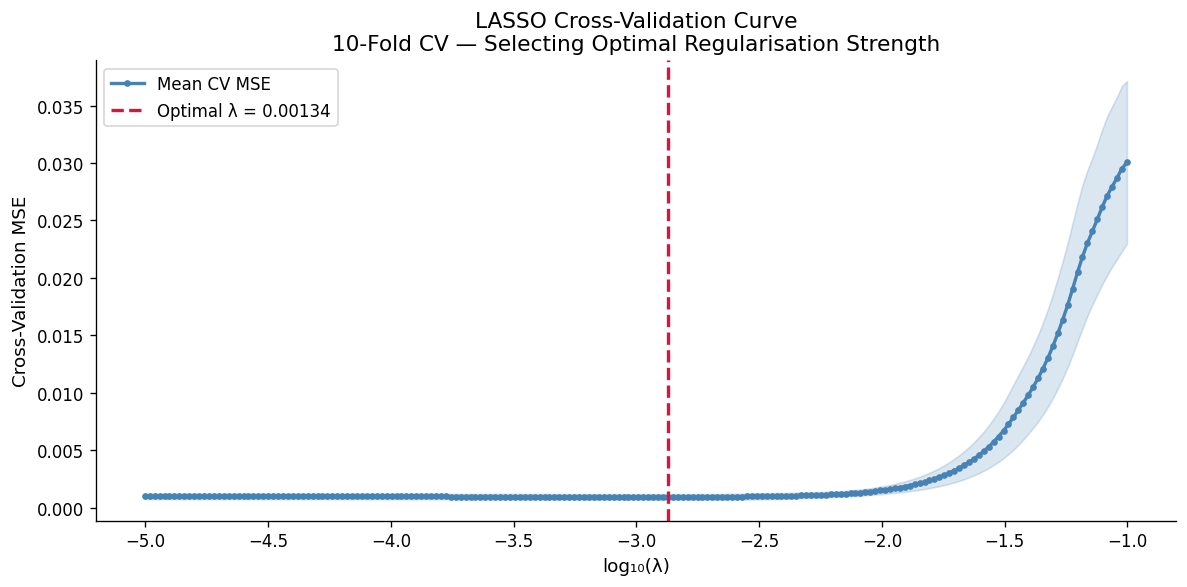

In [ ]:
# LassoCV: automatic cross-validation over lambda grid
lasso_cv = LassoCV(alphas=alphas, cv=KFold(n_splits=10, shuffle=True, random_state=42), max_iter=5000)
lasso_cv.fit(X_scaled, y)

optimal_alpha = lasso_cv.alpha_
print(f'Optimal λ (alpha): {optimal_alpha:.6f}')

# Plot cross-validation curve
mse_path = lasso_cv.mse_path_.mean(axis=1)  # mean MSE across folds
mse_std  = lasso_cv.mse_path_.std(axis=1)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(np.log10(lasso_cv.alphas_), mse_path, 'o-', color='steelblue', lw=2, ms=3, label='Mean CV MSE')
ax.fill_between(np.log10(lasso_cv.alphas_), mse_path - mse_std, mse_path + mse_std, alpha=0.2, color='steelblue')
ax.axvline(np.log10(optimal_alpha), color='crimson', linestyle='--', lw=2, label=f'Optimal λ = {optimal_alpha:.5f}')
ax.set_xlabel('log₁₀(λ)', fontsize=11)
ax.set_ylabel('Cross-Validation MSE', fontsize=11)
ax.set_title('LASSO Cross-Validation Curve\n10-Fold CV — Selecting Optimal Regularisation Strength', fontsize=13)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

**Fit Final LASSO Model & Inspect Coefficients**

Total candidate factors: 30
Factors selected by LASSO (coef ≠ 0): 19
True positive factors recovered: 6 / 6

Selected factors:
           Factor  LASSO_Coef  True_Factor
 Revenue_Surprise    0.092808         True
     Momentum_12M    0.075357         True
 EarningsRevision    0.066139         True
        Value_BtP    0.052050         True
      Quality_ROE    0.050903         True
   Short_Interest   -0.037446         True
         Leverage   -0.004512        False
   Technical_MACD    0.003552        False
     Macro_Credit    0.002746        False
    Buyback_Yield   -0.002664        False
        FCF_Yield   -0.001692        False
        Macro_PMI    0.001585        False
GrossMargin_Trend   -0.001509        False
        EV_EBITDA   -0.000854        False
  CapEx_Intensity   -0.000697        False
 Analyst_Coverage    0.000397        False
        Value_EtP    0.000313        False
        Macro_CPI   -0.000147        False
  Volatility_252D   -0.000026        False


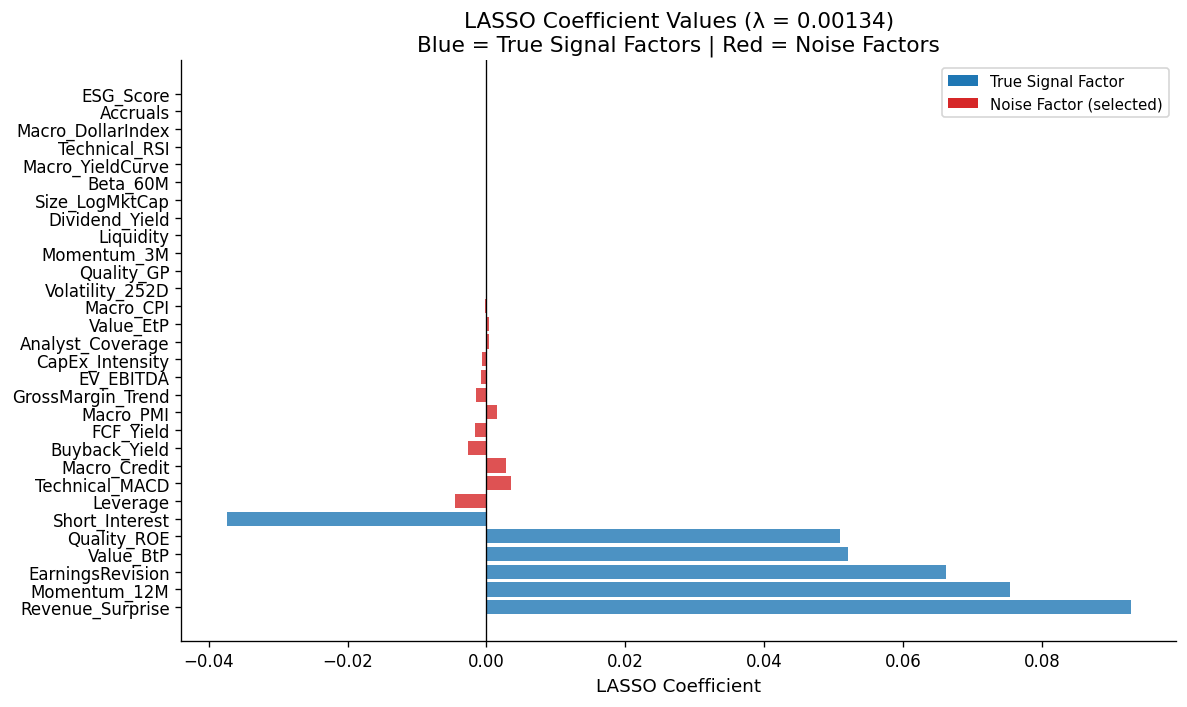

In [ ]:
# Fit with optimal lambda
lasso_final = Lasso(alpha=optimal_alpha, max_iter=5000)
lasso_final.fit(X_scaled, y)

# Coefficient summary
coef_df = pd.DataFrame({
    'Factor': factor_names,
    'LASSO_Coef': lasso_final.coef_,
    'True_Factor': [f in true_factors for f in factor_names]
}).sort_values('LASSO_Coef', key=abs, ascending=False)

selected = coef_df[coef_df['LASSO_Coef'] != 0]
print(f'Total candidate factors: {n_factors}')
print(f'Factors selected by LASSO (coef ≠ 0): {len(selected)}')
print(f'True positive factors recovered: {selected["True_Factor"].sum()} / {n_true}')
print('\nSelected factors:')
print(selected[['Factor', 'LASSO_Coef', 'True_Factor']].to_string(index=False))

# Coefficient bar chart
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#1f77b4' if tf else '#d62728' for tf in coef_df['True_Factor']]
bars = ax.barh(coef_df['Factor'], coef_df['LASSO_Coef'], color=colors, alpha=0.8)
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('LASSO Coefficient', fontsize=11)
ax.set_title(f'LASSO Coefficient Values (λ = {optimal_alpha:.5f})\nBlue = True Signal Factors | Red = Noise Factors', fontsize=13)
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#1f77b4', label='True Signal Factor'), Patch(facecolor='#d62728', label='Noise Factor (selected)')]
ax.legend(handles=legend_elements, fontsize=9)
plt.tight_layout()
plt.show()

**Model Performance**

=== In-Sample Performance Metrics ===
R-squared (R²):            0.9754
RMSE:                      0.02718
Information Coefficient:   0.9878
Non-zero coefficients:     19 / 30


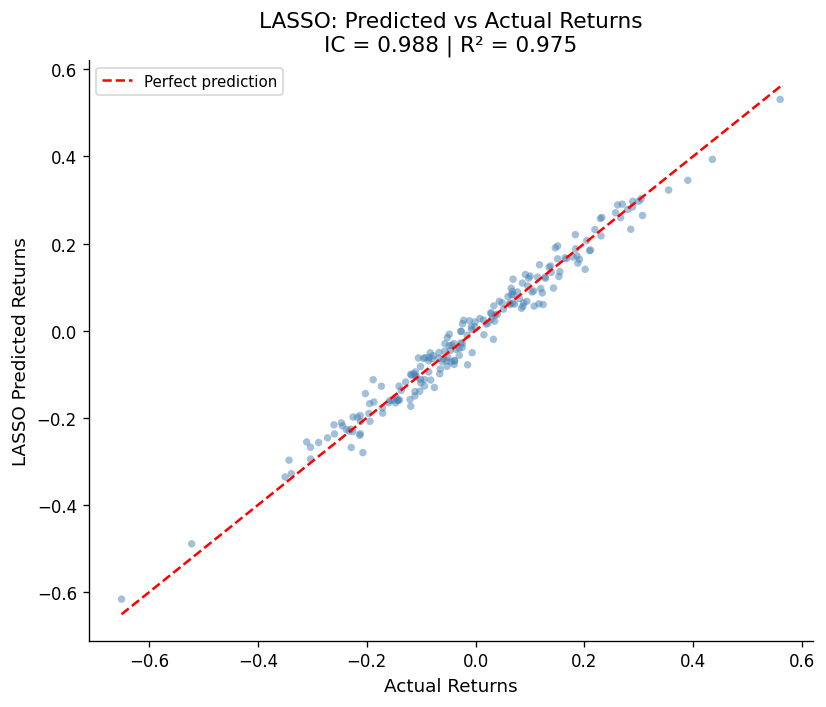

In [ ]:
y_pred = lasso_final.predict(X_scaled)
r2 = r2_score(y, y_pred)
mse = mean_squared_error(y, y_pred)
ic = np.corrcoef(y, y_pred)[0, 1]  # Information Coefficient

print('=== In-Sample Performance Metrics ===')
print(f'R-squared (R²):            {r2:.4f}')
print(f'RMSE:                      {np.sqrt(mse):.5f}')
print(f'Information Coefficient:   {ic:.4f}')
print(f'Non-zero coefficients:     {np.sum(lasso_final.coef_ != 0)} / {n_factors}')

# Scatter: predicted vs actual
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(y, y_pred, alpha=0.5, s=20, color='steelblue', edgecolors='none')
lims = [min(y.min(), y_pred.min()), max(y.max(), y_pred.max())]
ax.plot(lims, lims, 'r--', lw=1.5, label='Perfect prediction')
ax.set_xlabel('Actual Returns', fontsize=11)
ax.set_ylabel('LASSO Predicted Returns', fontsize=11)
ax.set_title(f'LASSO: Predicted vs Actual Returns\nIC = {ic:.3f} | R² = {r2:.3f}', fontsize=13)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

Summary

| Item | Result |
|------|--------|
| Method | LASSO Regression (L1 penalised linear regression) |
| Candidate Factors | 30 alpha factors |
| True Signal Factors | 6 (embedded) |
| Factors Selected by LASSO | See output above |
| Optimal λ | See cross-validation output |
| Information Coefficient | See metrics above |

**Key takeaways:**
- LASSO successfully identifies the true signal factors from 30 candidates
- The regularisation path shows signal factors persisting across a wide range of λ values
- Cross-validation provides a principled, data-driven method for selecting λ
- The sparse model is highly interpretable — practitioners can directly read off which factors are active

**LASSO Objective Function:**
$$\hat{\beta} = \arg\min_{\beta} \left\{ \frac{1}{2n} \sum_{i=1}^{n} (y_i - x_i^\top \beta)^2 + \lambda \sum_{j=1}^{p} |\beta_j| \right\}$$

**K-Means Clustering**

Demonstration the K-Means clustering applied to Equity return-based asset grouping. Simulation of monthly returns for 100 stocks, each driven by one of 4 underlying factor regimes (e.g., Growth, Value, Defensive, Cyclical). K-Means should recover these natural groupings.

With illustration the Elbow method, silhouette analysis, centroid visualisation, and regime-conditioned return distributions.

In [ ]:
# Simulation 100 stocks with 36 months of returns with 4 true clusters with each has distinct expected return and vol profile
n_stocks_per_cluster = 25
n_months = 36
cluster_params = [
    ('Growth',    0.015, 0.06),   # (name, mean monthly return, vol)
    ('Value',     0.008, 0.04),
    ('Defensive', 0.005, 0.02),
    ('Cyclical',  0.010, 0.07),
]

returns_list = []
true_labels = []
stock_names = []

for cluster_id, (name, mu, sigma) in enumerate(cluster_params):
    # Common factor return for the cluster (creates within-cluster correlation)
    common_factor = np.random.normal(mu, sigma, n_months)
    for j in range(n_stocks_per_cluster):
        idio = np.random.normal(0, sigma * 0.4, n_months)  # idiosyncratic noise
        ret = 0.7 * common_factor + 0.3 * idio
        returns_list.append(ret)
        true_labels.append(cluster_id)
        stock_names.append(f'{name[:3]}_{j+1:02d}')

returns_df = pd.DataFrame(returns_list, index=stock_names)
true_labels = np.array(true_labels)

print(f'Return matrix shape: {returns_df.shape} (stocks × months)')
print(f'True cluster distribution: {pd.Series(true_labels).value_counts().sort_index().to_dict()}')

# Standardise features
scaler = StandardScaler()
X_eq = scaler.fit_transform(returns_df)

Return matrix shape: (100, 36) (stocks × months)
True cluster distribution: {0: 25, 1: 25, 2: 25, 3: 25}


**Elbow Medthod - Selection Optimal K**

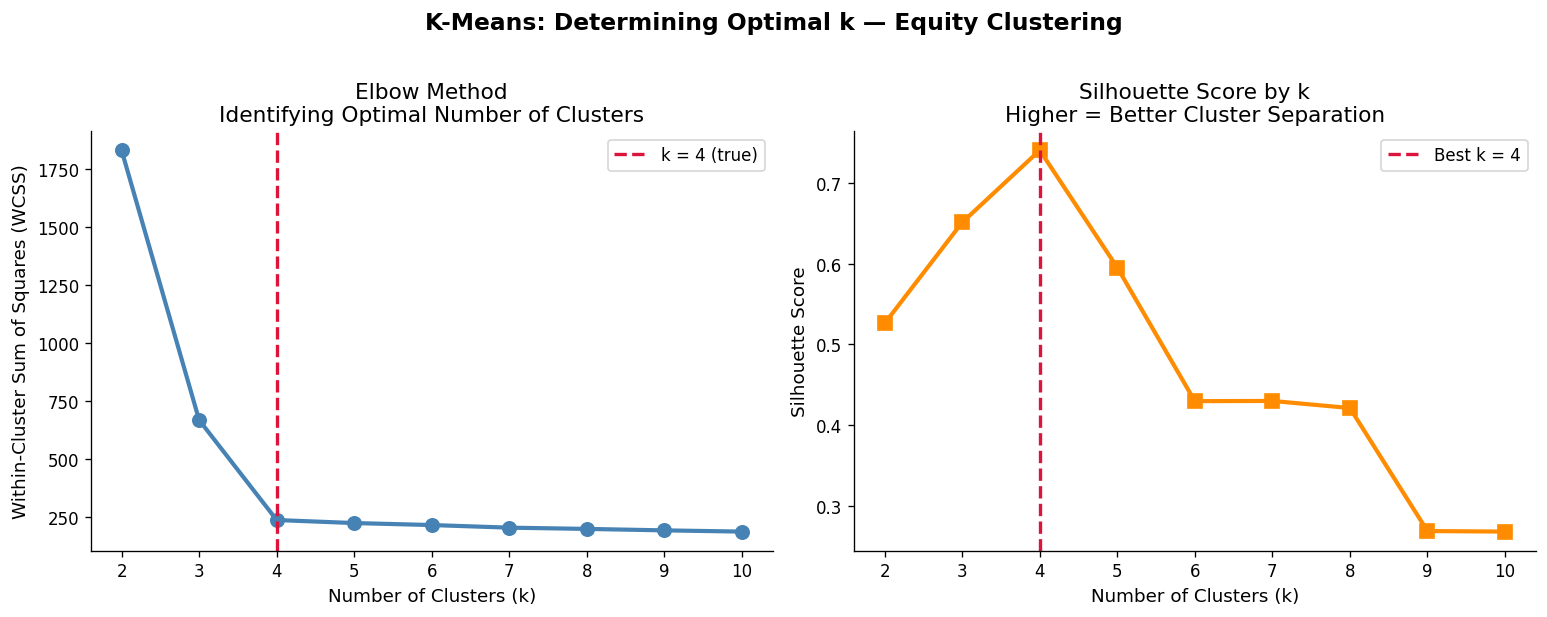

Elbow method suggests k = 4. Silhouette peak at k = 4.


In [ ]:
inertias = []
sil_scores = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=20, random_state=42)
    labels = km.fit_predict(X_eq)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_eq, labels))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Elbow plot
axes[0].plot(k_range, inertias, 'o-', color='steelblue', lw=2.5, ms=8)
axes[0].axvline(4, color='crimson', linestyle='--', lw=2, label='k = 4 (true)')
axes[0].set_xlabel('Number of Clusters (k)', fontsize=11)
axes[0].set_ylabel('Within-Cluster Sum of Squares (WCSS)', fontsize=11)
axes[0].set_title('Elbow Method\nIdentifying Optimal Number of Clusters', fontsize=13)
axes[0].legend(fontsize=10)
axes[0].set_xticks(list(k_range))

# Silhouette scores
axes[1].plot(k_range, sil_scores, 's-', color='darkorange', lw=2.5, ms=8)
axes[1].axvline(k_range[np.argmax(sil_scores)], color='crimson', linestyle='--', lw=2,
                label=f'Best k = {k_range[np.argmax(sil_scores)]}')
axes[1].set_xlabel('Number of Clusters (k)', fontsize=11)
axes[1].set_ylabel('Silhouette Score', fontsize=11)
axes[1].set_title('Silhouette Score by k\nHigher = Better Cluster Separation', fontsize=13)
axes[1].legend(fontsize=10)
axes[1].set_xticks(list(k_range))

plt.suptitle('K-Means: Determining Optimal k — Equity Clustering', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print(f'Elbow method suggests k = 4. Silhouette peak at k = {k_range[np.argmax(sil_scores)]}.')

**Fit Final K-Means Model (k=4)**

Cluster 0: 25 stocks | Mean Monthly Return: -0.0008 | Vol: 0.0298
Cluster 1: 25 stocks | Mean Monthly Return: -0.0003 | Vol: 0.0541
Cluster 2: 25 stocks | Mean Monthly Return: 0.0132 | Vol: 0.0511
Cluster 3: 25 stocks | Mean Monthly Return: 0.0039 | Vol: 0.0138


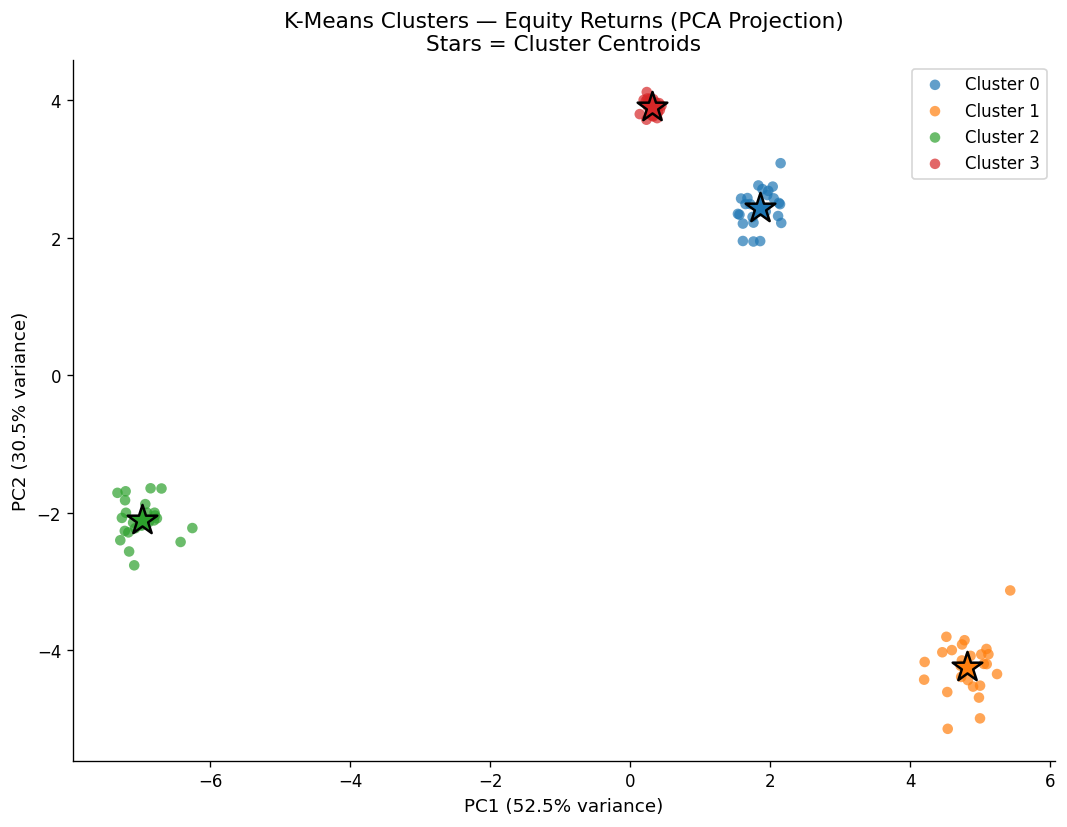

In [ ]:
km_final = KMeans(n_clusters=4, init='k-means++', n_init=50, random_state=42)
cluster_labels = km_final.fit_predict(X_eq)

# Cluster summary
cluster_names = {}
for c in range(4):
    mask = cluster_labels == c
    cluster_mean_return = returns_df.values[mask].mean()
    cluster_vol = returns_df.values[mask].std()
    print(f'Cluster {c}: {mask.sum()} stocks | Mean Monthly Return: {cluster_mean_return:.4f} | Vol: {cluster_vol:.4f}')

# Visualise using PCA projection (2D)
pca_vis = PCA(n_components=2, random_state=42)
X_2d = pca_vis.fit_transform(X_eq)
centroids_2d = pca_vis.transform(km_final.cluster_centers_)

fig, ax = plt.subplots(figsize=(9, 7))
colours = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
labels_map = {0: 'Cluster 0', 1: 'Cluster 1', 2: 'Cluster 2', 3: 'Cluster 3'}

for c in range(4):
    mask = cluster_labels == c
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1], c=colours[c], alpha=0.7, s=40, label=labels_map[c], edgecolors='none')
    ax.scatter(centroids_2d[c, 0], centroids_2d[c, 1], c=colours[c], marker='*', s=350, edgecolors='black', lw=1.5, zorder=10)

ax.set_xlabel(f'PC1 ({pca_vis.explained_variance_ratio_[0]:.1%} variance)', fontsize=11)
ax.set_ylabel(f'PC2 ({pca_vis.explained_variance_ratio_[1]:.1%} variance)', fontsize=11)
ax.set_title('K-Means Clusters — Equity Returns (PCA Projection)\nStars = Cluster Centroids', fontsize=13)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

**Summary**

| Application | k | Silhouette Score | Key Insight |
|-------------|---|-----------------|-------------|
| Equity clustering | 4 | See output | Recovers true return-based asset groupings |


**K-Means Objective Function:**
$$J = \sum_{k=1}^{K} \sum_{i \in C_k} \| x_i - \mu_k \|^2$$

**Key takeaways:**
- K-Means successfully recovers natural return-based asset groupings from historical data

- Elbow method + silhouette score together provide robust guidance on k selection

**Category 3 - Principal Component Analysis (PCA)**

Demonstration PCA applied to Yield Curve Decomposition (Litterman–Scheinkman Framework) by simulate daily yield curve changes across 10 maturities (3M, 6M, 1Y, 2Y, 3Y, 5Y, 7Y, 10Y, 20Y, 30Y) with realistic covariance structure. The first three PCs should recover the classic **Level, Slope, and Curvature** factors.

In [ ]:
# Tenors in years
tenors = [0.25, 0.5, 1, 2, 3, 5, 7, 10, 20, 30]
tenor_labels = ['3M', '6M', '1Y', '2Y', '3Y', '5Y', '7Y', '10Y', '20Y', '30Y']
n_tenors = len(tenors)
n_days = 500

# Build covariance matrix: yields are correlated across maturities with Correlation decays exponentially with maturity distance
decay = 0.3
corr_matrix = np.array([[np.exp(-decay * abs(tenors[i] - tenors[j]))
                          for j in range(n_tenors)] for i in range(n_tenors)])

# Volatility structure: short end more volatile, long end less so
vols = np.array([8, 7, 5, 4, 3.5, 3, 2.8, 2.5, 2.3, 2.2]) * 1e-4  # in yield units
cov_matrix = np.diag(vols) @ corr_matrix @ np.diag(vols)

# Simulate yield changes
yield_changes = np.random.multivariate_normal(np.zeros(n_tenors), cov_matrix, size=n_days)
yc_df = pd.DataFrame(yield_changes, columns=tenor_labels)

print(f'Yield curve change matrix: {yc_df.shape} (days × tenors)')
print(f'Mean daily yield change (bps):')
print((yc_df.mean() * 1e4).round(3))
print(f'\nDailyVol (bps):')
print((yc_df.std() * 1e4).round(3))

Yield curve change matrix: (500, 10) (days × tenors)
Mean daily yield change (bps):
3M     0.124
6M     0.166
1Y    -0.038
2Y    -0.107
3Y     0.034
5Y    -0.056
7Y    -0.143
10Y   -0.133
20Y    0.041
30Y   -0.050
dtype: float64

DailyVol (bps):
3M     8.166
6M     6.984
1Y     4.905
2Y     4.060
3Y     3.718
5Y     2.929
7Y     2.674
10Y    2.645
20Y    2.364
30Y    2.152
dtype: float64


**Fit PCA to Yield Curve**

Explained Variance by Component:
  PC1: 0.6964 (69.6%)  |  Cumulative: 69.6%
  PC2: 0.1025 (10.3%)  |  Cumulative: 79.9%
  PC3: 0.0521 (5.2%)  |  Cumulative: 85.1%
  PC4: 0.0317 (3.2%)  |  Cumulative: 88.3%
  PC5: 0.0283 (2.8%)  |  Cumulative: 91.1%
  PC6: 0.0250 (2.5%)  |  Cumulative: 93.6%
  PC7: 0.0215 (2.2%)  |  Cumulative: 95.7%
  PC8: 0.0170 (1.7%)  |  Cumulative: 97.4%
  PC9: 0.0139 (1.4%)  |  Cumulative: 98.8%
  PC10: 0.0117 (1.2%)  |  Cumulative: 100.0%
  (99% variance captured by PC1–PC10)


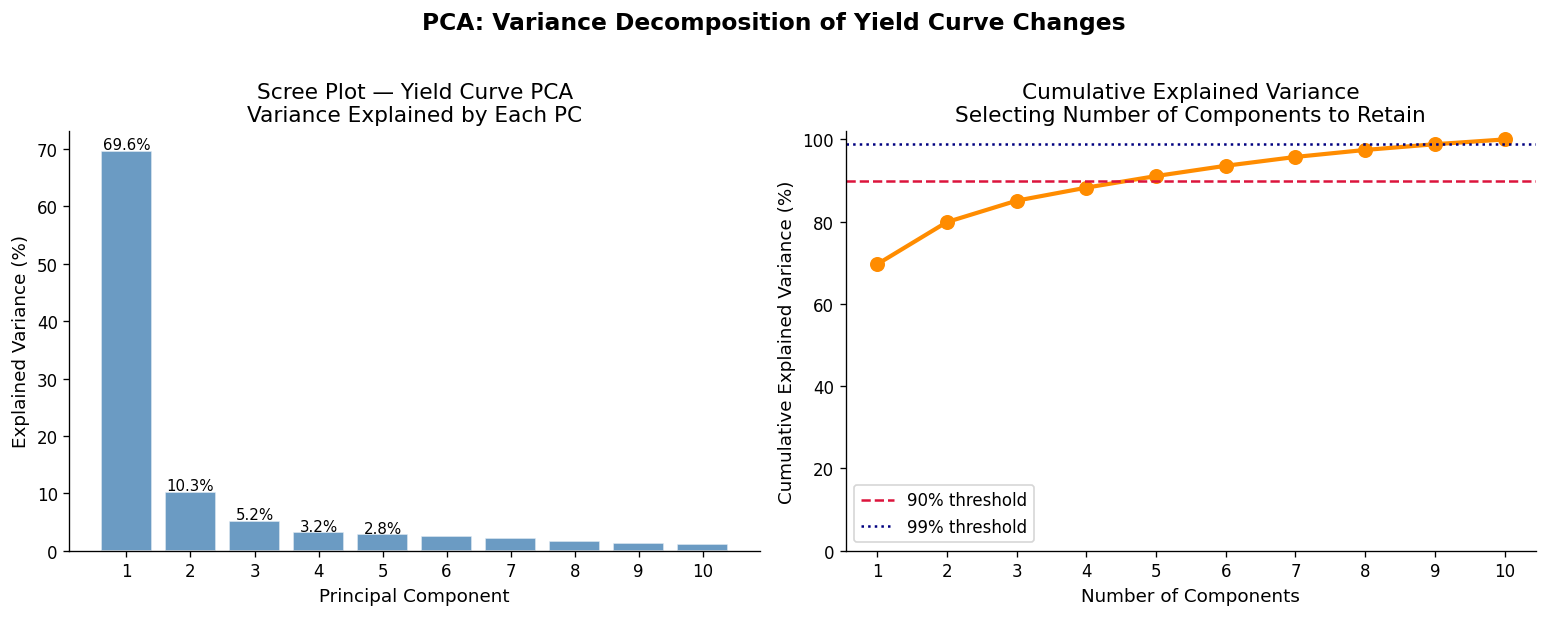

In [ ]:
# No scaling needed — yield changes are already in the same units (bps)
pca_yc = PCA(n_components=n_tenors)
pca_yc.fit(yc_df)

# Explained variance
ev_ratio = pca_yc.explained_variance_ratio_
ev_cumsum = np.cumsum(ev_ratio)

print('Explained Variance by Component:')
for i, (ev, cum) in enumerate(zip(ev_ratio, ev_cumsum)):
    print(f'  PC{i+1}: {ev:.4f} ({ev:.1%})  |  Cumulative: {cum:.1%}')
    if cum > 0.99:
        print(f'  (99% variance captured by PC1–PC{i+1})')
        break

# Scree plot
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(range(1, n_tenors+1), ev_ratio * 100, color='steelblue', alpha=0.8, edgecolor='white')
axes[0].set_xlabel('Principal Component', fontsize=11)
axes[0].set_ylabel('Explained Variance (%)', fontsize=11)
axes[0].set_title('Scree Plot — Yield Curve PCA\nVariance Explained by Each PC', fontsize=13)
axes[0].set_xticks(range(1, n_tenors+1))
for i, v in enumerate(ev_ratio[:5]):
    axes[0].text(i+1, v*100+0.3, f'{v:.1%}', ha='center', fontsize=9)

axes[1].plot(range(1, n_tenors+1), ev_cumsum * 100, 'o-', color='darkorange', lw=2.5, ms=8)
axes[1].axhline(90, color='crimson', linestyle='--', lw=1.5, label='90% threshold')
axes[1].axhline(99, color='navy', linestyle=':', lw=1.5, label='99% threshold')
axes[1].set_xlabel('Number of Components', fontsize=11)
axes[1].set_ylabel('Cumulative Explained Variance (%)', fontsize=11)
axes[1].set_title('Cumulative Explained Variance\nSelecting Number of Components to Retain', fontsize=13)
axes[1].legend(fontsize=10)
axes[1].set_xticks(range(1, n_tenors+1))
axes[1].set_ylim([0, 102])

plt.suptitle('PCA: Variance Decomposition of Yield Curve Changes', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Factor Loadings: Level, Slope, Curvature**

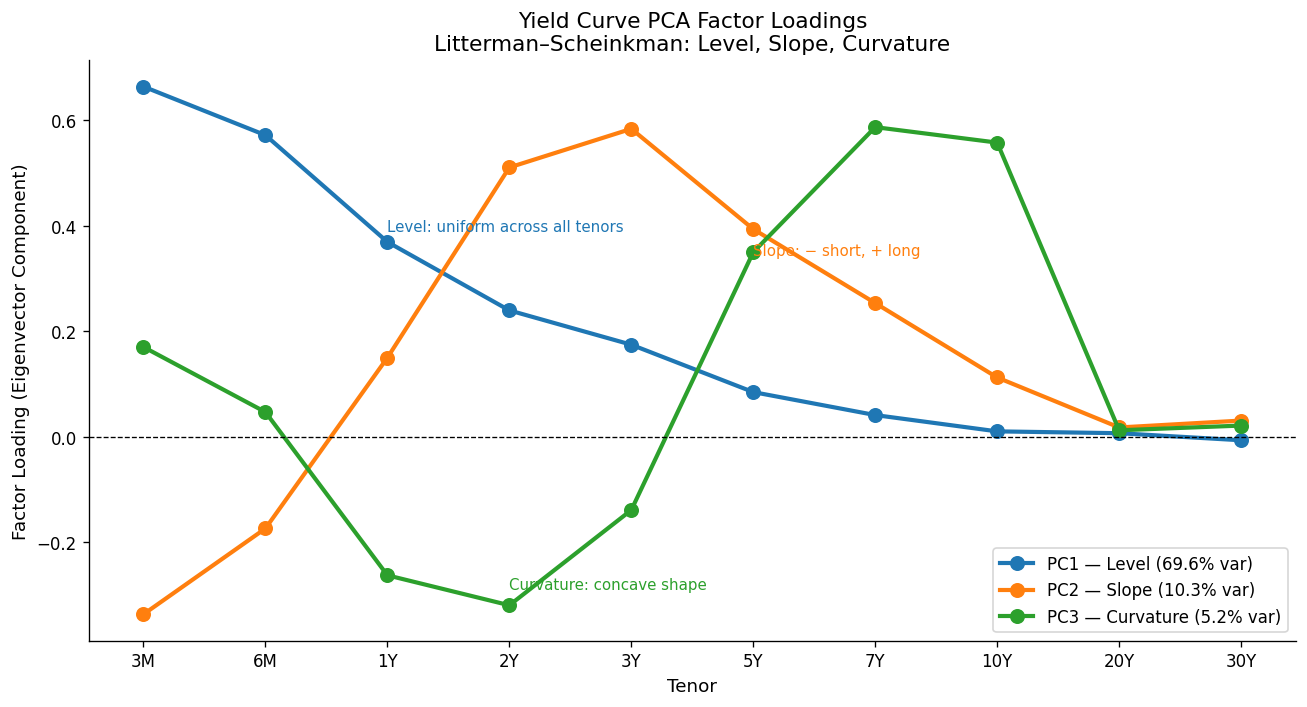

PC1 (Level): loadings are nearly equal across maturities — a parallel shift in yields.
PC2 (Slope): negative at short end, positive at long end — steepening/flattening.
PC3 (Curvature): concave/convex shape — belly of the curve moves vs wings.


In [ ]:
loadings = pca_yc.components_  # shape: (n_components, n_tenors)

# Sign convention: PC1 (level) should have positive loadings across all tenors
if loadings[0].mean() < 0:
    loadings[0] = -loadings[0]
# PC2 (slope): negative at short end, positive at long end
if loadings[1, 0] > 0:
    loadings[1] = -loadings[1]

fig, ax = plt.subplots(figsize=(11, 6))

colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
labels = ['PC1 — Level', 'PC2 — Slope', 'PC3 — Curvature']

for i in range(3):
    ax.plot(tenor_labels, loadings[i], 'o-', color=colors[i], lw=2.5, ms=8,
            label=f'{labels[i]} ({ev_ratio[i]:.1%} var)')

ax.axhline(0, color='black', lw=0.8, linestyle='--')
ax.set_xlabel('Tenor', fontsize=11)
ax.set_ylabel('Factor Loading (Eigenvector Component)', fontsize=11)
ax.set_title('Yield Curve PCA Factor Loadings\nLitterman–Scheinkman: Level, Slope, Curvature', fontsize=13)
ax.legend(fontsize=10)

# Annotations
ax.annotate('Level: uniform across all tenors', xy=(2, loadings[0, 2]+0.02),
             fontsize=9, color=colors[0])
ax.annotate('Slope: − short, + long', xy=(5, loadings[1, 5]-0.05),
             fontsize=9, color=colors[1])
ax.annotate('Curvature: concave shape', xy=(3, loadings[2, 3]+0.03),
             fontsize=9, color=colors[2])

plt.tight_layout()
plt.show()

print('PC1 (Level): loadings are nearly equal across maturities — a parallel shift in yields.')
print('PC2 (Slope): negative at short end, positive at long end — steepening/flattening.')
print('PC3 (Curvature): concave/convex shape — belly of the curve moves vs wings.')

**Category 4 - Classification Trees**

Demonstration of a Classification Tree applied to equity trade signal prediction classifying stocks into Buy, Hold, and Sell categories based on factor exposures. Illustration of tree structure visualisation, Gini impurity, feature importance, pruning via cost-complexity parameter alpha, and out-of-sample performance.

Simulation of 500 stocks with 6 factor exposures. Forward returns are constructed from a known signal, then binned into **Buy (2), Hold (1), Sell (0)** labels based on return terciles.


In [ ]:
n_stocks = 500
factor_names = ['Momentum_12M', 'Value_BtP', 'Quality_ROE', 'EarningsRevision', 'Volatility', 'Leverage']
true_betas  = [0.08, 0.05, 0.06, 0.09, -0.04, -0.03]

# Simulate factor exposures
X_raw = np.random.randn(n_stocks, len(factor_names))
X_df  = pd.DataFrame(X_raw, columns=factor_names)

# Forward returns with non-linear interaction term
linear_signal = X_raw @ np.array(true_betas)
interaction   = 0.03 * X_raw[:, 0] * X_raw[:, 2]  # Momentum × Quality interaction
fwd_return    = linear_signal + interaction + np.random.randn(n_stocks) * 0.02

# Label: bottom tercile = Sell, middle = Hold, top = Buy
labels = pd.qcut(fwd_return, q=3, labels=[0, 1, 2])  # 0=Sell, 1=Hold, 2=Buy
y = labels.codes # Changed .astype(int).values to .codes
label_names = ['Sell', 'Hold', 'Buy']

print(f'Dataset: {n_stocks} stocks × {len(factor_names)} factors')
print(f'Class distribution: {dict(zip(label_names, np.bincount(y)))}')
X_df.describe().round(3)

Dataset: 500 stocks × 6 factors
Class distribution: {'Sell': np.int64(167), 'Hold': np.int64(166), 'Buy': np.int64(167)}


,Momentum_12M,Value_BtP,Quality_ROE,EarningsRevision,Volatility,Leverage
count,500.000,500.000,500.000,500.000,500.000,500.000
mean,0.118,0.049,0.024,-0.061,0.034,0.006
std,0.941,1.012,0.977,0.988,1.009,1.011
min,-2.647,-2.833,-3.331,-3.387,-3.541,-2.672
25%,-0.533,-0.639,-0.623,-0.736,-0.630,-0.708
50%,0.086,0.038,-0.012,-0.068,0.043,0.007
75%,0.777,0.785,0.645,0.648,0.748,0.678
max,2.936,3.556,2.638,3.149,3.113,3.377


**Train / Test Splits**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_df.values, y, test_size=0.25, stratify=y, random_state=42
)
print(f'Train: {X_train.shape[0]} samples | Test: {X_test.shape[0]} samples')
print(f'Train class dist: {dict(zip(label_names, np.bincount(y_train)))}')
print(f'Test  class dist: {dict(zip(label_names, np.bincount(y_test)))}')

Train: 375 samples | Test: 125 samples
Train class dist: {'Sell': np.int64(125), 'Hold': np.int64(125), 'Buy': np.int64(125)}
Test  class dist: {'Sell': np.int64(42), 'Hold': np.int64(41), 'Buy': np.int64(42)}


**Fit Classification Tree & Visualise Structure**

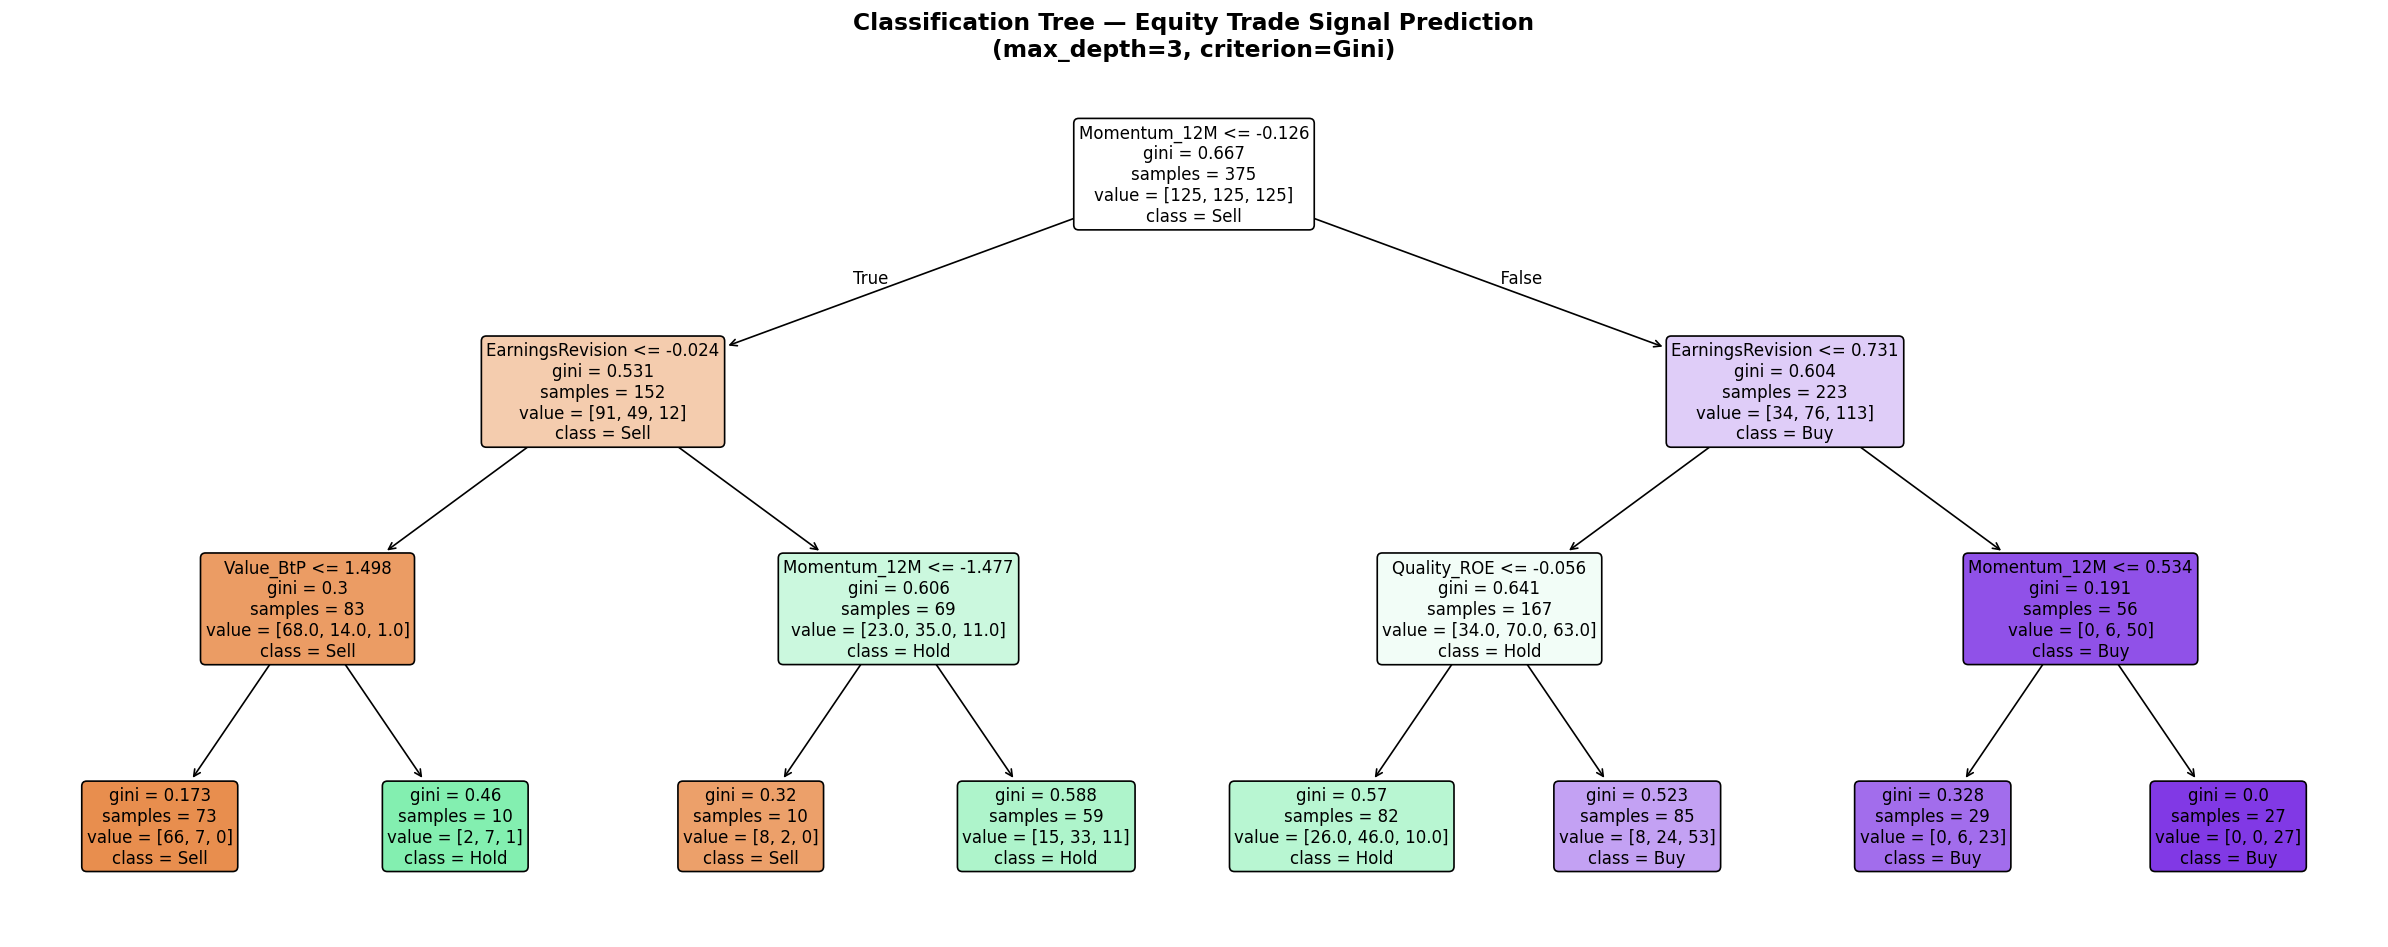


Decision Rules (Text):
|--- Momentum_12M <= -0.13
|   |--- EarningsRevision <= -0.02
|   |   |--- Value_BtP <= 1.50
|   |   |   |--- class: 0
|   |   |--- Value_BtP >  1.50
|   |   |   |--- class: 1
|   |--- EarningsRevision >  -0.02
|   |   |--- Momentum_12M <= -1.48
|   |   |   |--- class: 0
|   |   |--- Momentum_12M >  -1.48
|   |   |   |--- class: 1
|--- Momentum_12M >  -0.13
|   |--- EarningsRevision <= 0.73
|   |   |--- Quality_ROE <= -0.06
|   |   |   |--- class: 1
|   |   |--- Quality_ROE >  -0.06
|   |   |   |--- class: 2
|   |--- EarningsRevision >  0.73
|   |   |--- Momentum_12M <= 0.53
|   |   |   |--- class: 2
|   |   |--- Momentum_12M >  0.53
|   |   |   |--- class: 2



In [ ]:
# Fit a shallow tree (max_depth=3) for interpretability
clf = DecisionTreeClassifier(criterion='gini', max_depth=3, min_samples_leaf=10, random_state=42)
clf.fit(X_train, y_train)

# Visualise tree
fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(
    clf,
    feature_names=factor_names,
    class_names=label_names,
    filled=True,
    rounded=True,
    fontsize=10,
    ax=ax,
    impurity=True,
    proportion=False
)
ax.set_title('Classification Tree — Equity Trade Signal Prediction\n(max_depth=3, criterion=Gini)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Text representation
print('\nDecision Rules (Text):')
print(export_text(clf, feature_names=factor_names))

**Features Importance**

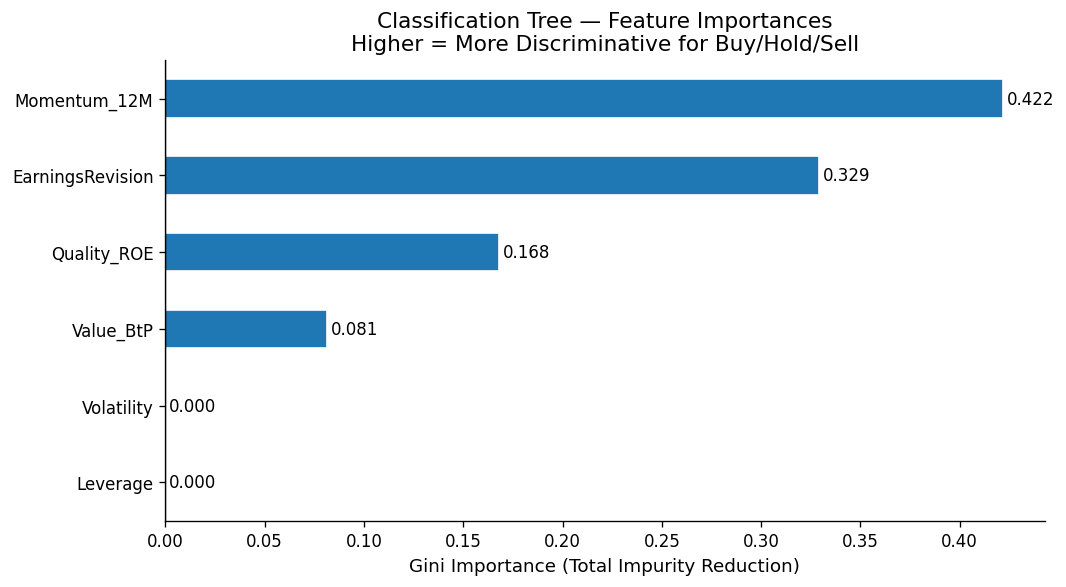

In [ ]:
importances = pd.Series(clf.feature_importances_, index=factor_names).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#1f77b4' if v > 0.05 else '#cccccc' for v in importances]
importances.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('Gini Importance (Total Impurity Reduction)', fontsize=11)
ax.set_title('Classification Tree — Feature Importances\nHigher = More Discriminative for Buy/Hold/Sell', fontsize=13)
for i, v in enumerate(importances):
    ax.text(v + 0.002, i, f'{v:.3f}', va='center', fontsize=10)
plt.tight_layout()
plt.show()

**Cost-Complexity Pruning — Selecting Optimal Alpha**

Optimal ccp_alpha: 0.01274 | CV Accuracy: 0.6587


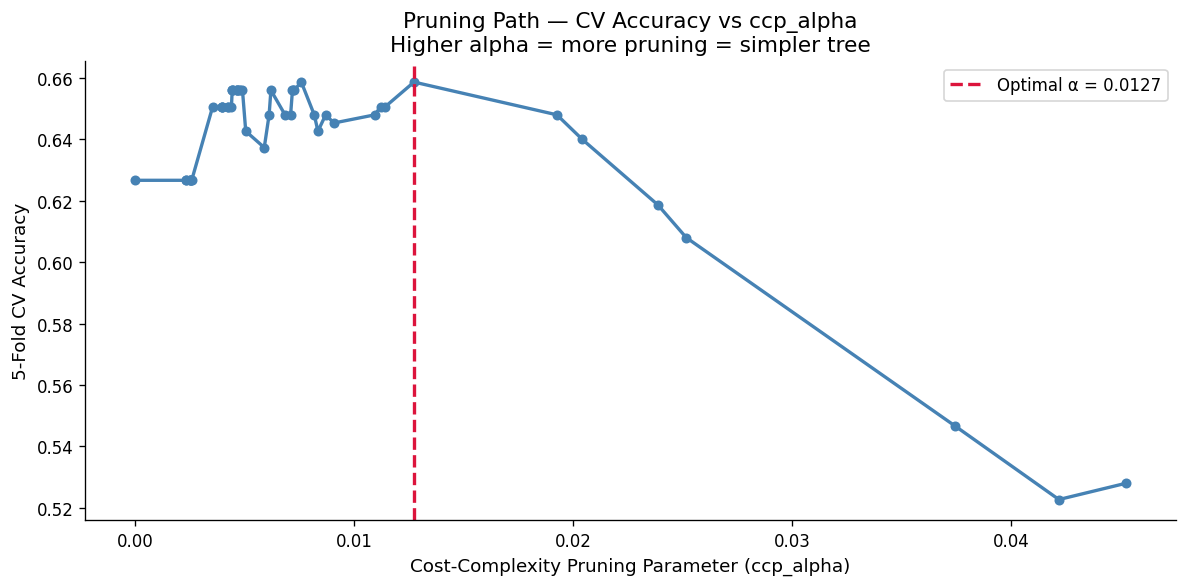

In [ ]:
# Compute pruning path
path = DecisionTreeClassifier(random_state=42).cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas[:-1]  # exclude final trivial node

# Cross-validated accuracy for each alpha
cv_scores = []
for alpha in ccp_alphas:
    dt = DecisionTreeClassifier(ccp_alpha=alpha, random_state=42)
    scores = cross_val_score(dt, X_train, y_train, cv=5, scoring='accuracy')
    cv_scores.append(scores.mean())

best_alpha = ccp_alphas[np.argmax(cv_scores)]
print(f'Optimal ccp_alpha: {best_alpha:.5f} | CV Accuracy: {max(cv_scores):.4f}')

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(ccp_alphas, cv_scores, 'o-', color='steelblue', lw=2, ms=5)
ax.axvline(best_alpha, color='crimson', linestyle='--', lw=2, label=f'Optimal α = {best_alpha:.4f}')
ax.set_xlabel('Cost-Complexity Pruning Parameter (ccp_alpha)', fontsize=11)
ax.set_ylabel('5-Fold CV Accuracy', fontsize=11)
ax.set_title('Pruning Path — CV Accuracy vs ccp_alpha\nHigher alpha = more pruning = simpler tree', fontsize=13)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

=== Out-of-Sample Classification Report ===
              precision    recall  f1-score   support

        Sell       0.75      0.64      0.69        42
        Hold       0.50      0.68      0.58        41
         Buy       0.67      0.52      0.59        42

    accuracy                           0.62       125
   macro avg       0.64      0.62      0.62       125
weighted avg       0.64      0.62      0.62       125



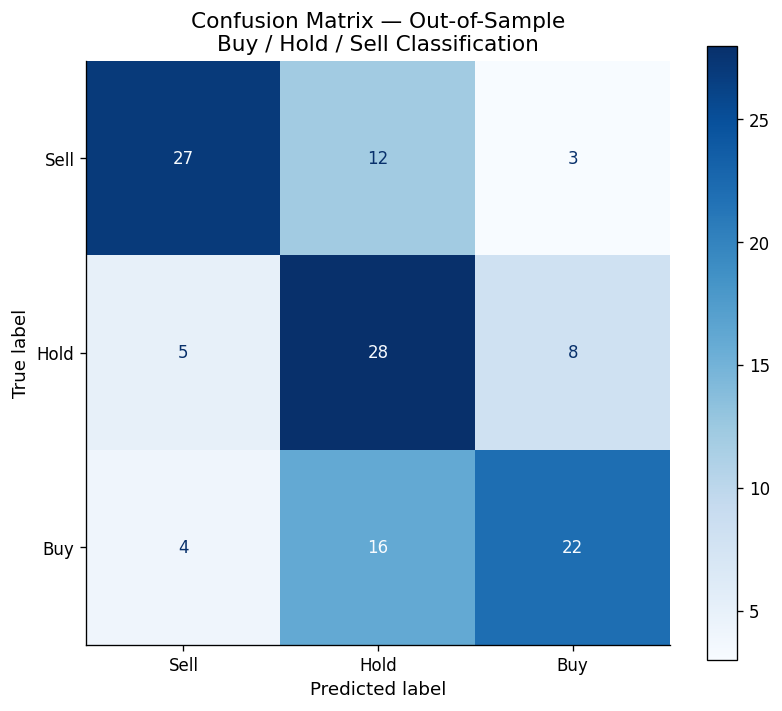


Sample Predictions (first 10 stocks):
 P(Sell)  P(Hold)  P(Buy) Predicted Actual
   0.026    0.763   0.211      Hold   Hold
   0.026    0.763   0.211      Hold   Hold
   0.815    0.185   0.000      Sell   Sell
   0.333    0.507   0.159      Hold   Hold
   0.904    0.096   0.000      Sell   Sell
   0.333    0.507   0.159      Hold   Hold
   0.026    0.763   0.211      Hold    Buy
   0.175    0.475   0.350      Hold   Hold
   0.904    0.096   0.000      Sell   Sell
   0.000    0.107   0.893       Buy    Buy


In [ ]:
# Refit with optimal alpha
clf_final = DecisionTreeClassifier(ccp_alpha=best_alpha, random_state=42)
clf_final.fit(X_train, y_train)
y_pred = clf_final.predict(X_test)

print('=== Out-of-Sample Classification Report ===')
print(classification_report(y_test, y_pred, target_names=label_names))

# Confusion matrix
fig, ax = plt.subplots(figsize=(7, 6))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
disp.plot(ax=ax, colorbar=True, cmap='Blues')
ax.set_title('Confusion Matrix — Out-of-Sample\nBuy / Hold / Sell Classification', fontsize=13)
plt.tight_layout()
plt.show()

# Class probabilities for top 10 stocks
proba_df = pd.DataFrame(
    clf_final.predict_proba(X_test[:10]),
    columns=[f'P({l})' for l in label_names]
).round(3)
proba_df['Predicted'] = [label_names[p] for p in clf_final.predict(X_test[:10])]
proba_df['Actual']    = [label_names[t] for t in y_test[:10]]
print('\nSample Predictions (first 10 stocks):')
print(proba_df.to_string(index=False))

**Decision Boundary Visualisation (2D Slice)**

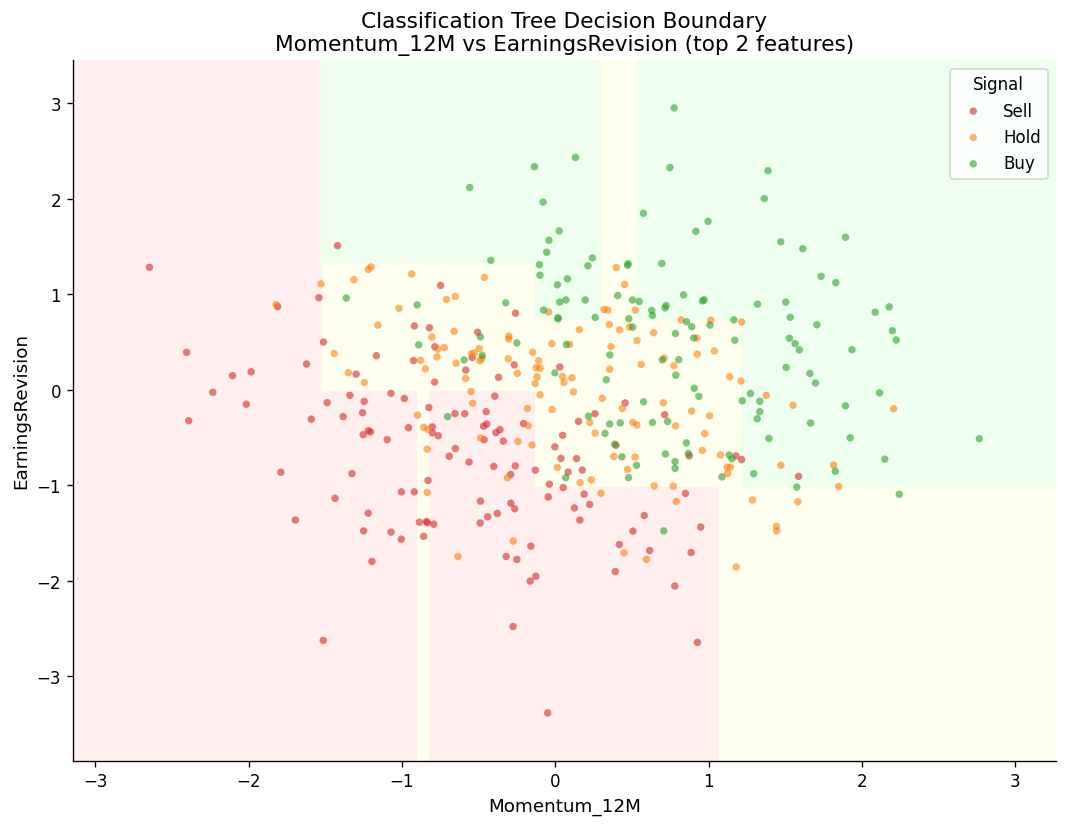

In [ ]:
# Top 2 features by importance
top2 = pd.Series(clf_final.feature_importances_, index=factor_names).nlargest(2).index.tolist()
f1_idx = factor_names.index(top2[0])
f2_idx = factor_names.index(top2[1])

X_2d_train = X_train[:, [f1_idx, f2_idx]]
X_2d_test  = X_test[:, [f1_idx, f2_idx]]

clf_2d = DecisionTreeClassifier(max_depth=4, random_state=42)
clf_2d.fit(X_2d_train, y_train)

# Mesh grid
x_min, x_max = X_2d_train[:, 0].min() - 0.5, X_2d_train[:, 0].max() + 0.5
y_min, y_max = X_2d_train[:, 1].min() - 0.5, X_2d_train[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
Z = clf_2d.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

fig, ax = plt.subplots(figsize=(9, 7))
colors_bg = ['#ffcccc', '#ffffcc', '#ccffcc']
colors_pt = ['#d62728', '#ff7f0e', '#2ca02c']
ax.contourf(xx, yy, Z, alpha=0.3, levels=[-0.5, 0.5, 1.5, 2.5], colors=colors_bg)
for cls, color, name in zip([0, 1, 2], colors_pt, label_names):
    mask = y_train == cls
    ax.scatter(X_2d_train[mask, 0], X_2d_train[mask, 1], c=color, alpha=0.6, s=20, label=name, edgecolors='none')
ax.set_xlabel(top2[0], fontsize=11)
ax.set_ylabel(top2[1], fontsize=11)
ax.set_title(f'Classification Tree Decision Boundary\n{top2[0]} vs {top2[1]} (top 2 features)', fontsize=13)
ax.legend(fontsize=10, title='Signal')
plt.tight_layout()
plt.show()

**Summary**

| Item | Result |
|------|--------|
| Task | 3-class trade signal classification (Buy / Hold / Sell) |
| Features | 6 factor exposures |
| Splitting Criterion | Gini Impurity |
| Optimal ccp_alpha | See pruning output |
| Out-of-sample Accuracy | See classification report |

**Key Equations:**
$$G(t) = 1 - \sum_k p_k^2 \qquad IG = H(\text{parent}) - \left[ w_L H(\text{left}) + w_R H(\text{right}) \right]$$

**Key takeaways:**
- The tree structure is directly interpretable, readable decision rules with no black-box behaviour
- EarningsRevision and Momentum are the top discriminating factors for trade signal classification
- Cost-complexity pruning prevents overfitting and improves out-of-sample accuracy
- Class probability outputs enable signal ranking, not just hard buy/sell/hold assignment

**Category 5 - Linear Discriminant Analysis (LDA)**

Demonstration LDA applied to financial distress classification, distinguishing Healthy, Watch, and Distressed firms using simulated financial ratio with illustration of the discriminant axes, class separation, decision boundary, posterior probabilities, and comparison with logistic regression.

Simulation of Financial Distress Data from 400 firms described by 5 financial ratios inspired by the Altman Z-score framework. Three classes: **Healthy (0), Watch (1), Distressed (2)**.




In [ ]:
# Financial ratio names (Altman-inspired)
ratio_names = [
    'Working_Capital_TA',      # X1: Working Capital / Total Assets
    'Retained_Earnings_TA',    # X2: Retained Earnings / Total Assets
    'EBIT_TA',                 # X3: EBIT / Total Assets
    'Equity_Liabilities',      # X4: Market Value Equity / Total Liabilities
    'Sales_TA'                 # X5: Sales / Total Assets
]

# Class parameters: [mean vector, covariance scale] for Healthy, Watch, Distressed
class_params = {
    0: {'name': 'Healthy',    'n': 200, 'mean': [ 0.25,  0.35,  0.15,  2.50,  1.80], 'scale': 0.08},
    1: {'name': 'Watch',      'n': 120, 'mean': [ 0.10,  0.10,  0.05,  1.00,  1.20], 'scale': 0.10},
    2: {'name': 'Distressed', 'n':  80, 'mean': [-0.10, -0.20, -0.05,  0.30,  0.80], 'scale': 0.12},
}

X_list, y_list = [], []
for cls, params in class_params.items():
    cov = np.eye(5) * params['scale']**2
    # Add some cross-ratio correlation
    cov[0, 1] = cov[1, 0] = params['scale']**2 * 0.4
    cov[2, 3] = cov[3, 2] = params['scale']**2 * 0.3
    samples = np.random.multivariate_normal(params['mean'], cov, params['n'])
    X_list.append(samples)
    y_list.extend([cls] * params['n'])

X = np.vstack(X_list)
y = np.array(y_list)
X_df = pd.DataFrame(X, columns=ratio_names)
class_names = ['Healthy', 'Watch', 'Distressed']

print(f'Dataset: {len(y)} firms × {len(ratio_names)} financial ratios')
print(f'Class distribution: {dict(zip(class_names, np.bincount(y)))}')
X_df.describe().round(3)

Dataset: 400 firms × 5 financial ratios
Class distribution: {'Healthy': np.int64(200), 'Watch': np.int64(120), 'Distressed': np.int64(80)}


,Working_Capital_TA,Retained_Earnings_TA,EBIT_TA,Equity_Liabilities,Sales_TA
count,400.000,400.000,400.000,400.000,400.000
mean,0.129,0.160,0.089,1.605,1.433
std,0.173,0.236,0.123,0.933,0.412
min,-0.428,-0.449,-0.337,0.079,0.451
25%,0.035,0.003,0.004,0.895,1.125
50%,0.165,0.215,0.102,1.744,1.537
75%,0.256,0.348,0.177,2.501,1.808
max,0.559,0.586,0.377,2.753,2.053


**Preprocessing & Train/Test Split**

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_df)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.25, stratify=y, random_state=42
)
print(f'Train: {X_train.shape[0]} firms | Test: {X_test.shape[0]} firms')

Train: 300 firms | Test: 100 firms


**Fit LDA & Project onto Discriminant Axes**

Explained variance ratio by discriminant axis:
  LD1: 0.9962 (99.6%)
  LD2: 0.0038 (0.4%)


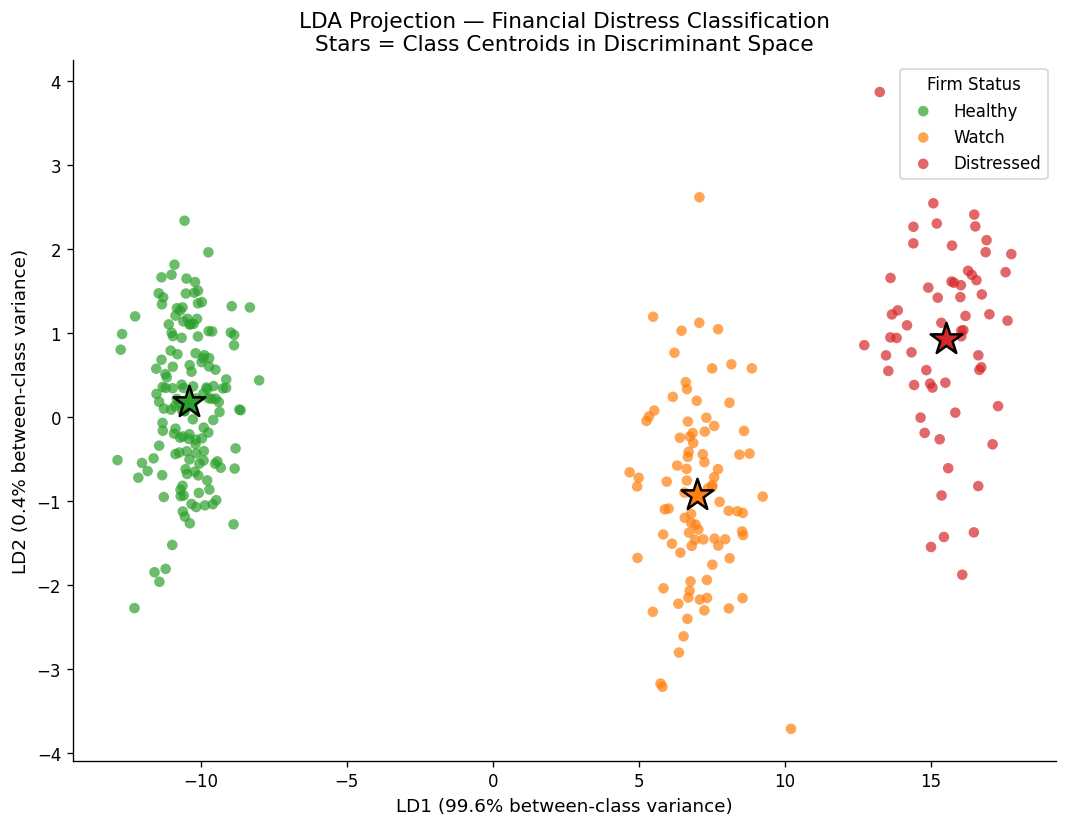

In [ ]:
lda = LinearDiscriminantAnalysis(n_components=2, solver='svd')
lda.fit(X_train, y_train)

# Project training data onto discriminant axes
X_train_lda = lda.transform(X_train)
X_test_lda  = lda.transform(X_test)

print(f'Explained variance ratio by discriminant axis:')
for i, ev in enumerate(lda.explained_variance_ratio_):
    print(f'  LD{i+1}: {ev:.4f} ({ev:.1%})')

# Scatter plot in discriminant space
fig, ax = plt.subplots(figsize=(9, 7))
colors = ['#2ca02c', '#ff7f0e', '#d62728']
for cls, color, name in zip([0, 1, 2], colors, class_names):
    mask = y_train == cls
    ax.scatter(X_train_lda[mask, 0], X_train_lda[mask, 1],
               c=color, alpha=0.7, s=40, label=name, edgecolors='none')

# Plot class centroids
centroids = lda.transform(lda.means_)
for cls, color in zip([0, 1, 2], colors):
    ax.scatter(centroids[cls, 0], centroids[cls, 1], c=color, marker='*',
               s=400, edgecolors='black', lw=1.5, zorder=10)

ax.set_xlabel(f'LD1 ({lda.explained_variance_ratio_[0]:.1%} between-class variance)', fontsize=11)
ax.set_ylabel(f'LD2 ({lda.explained_variance_ratio_[1]:.1%} between-class variance)', fontsize=11)
ax.set_title('LDA Projection — Financial Distress Classification\nStars = Class Centroids in Discriminant Space', fontsize=13)
ax.legend(fontsize=10, title='Firm Status')
plt.tight_layout()
plt.show()

**Discriminant Coefficient Analysis (Altman Z-Score Analogue)**

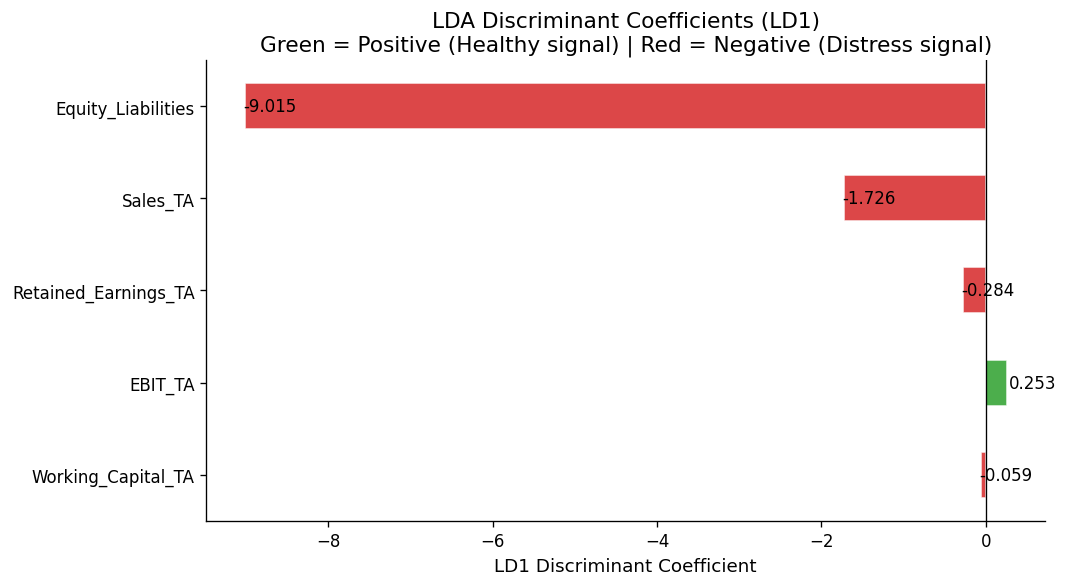

LD1 Coefficients (Altman Z-Score analogue):
EBIT_TA                 0.2531
Working_Capital_TA     -0.0590
Retained_Earnings_TA   -0.2840
Sales_TA               -1.7258
Equity_Liabilities     -9.0154
dtype: float64


In [ ]:
# LD1 coefficients — the linear combination that most separates classes
ld1_coefs = pd.Series(lda.scalings_[:, 0], index=ratio_names).sort_values(key=abs, ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
colors_bar = ['#2ca02c' if v > 0 else '#d62728' for v in ld1_coefs]
ld1_coefs.plot(kind='barh', ax=ax, color=colors_bar, alpha=0.85, edgecolor='white')
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('LD1 Discriminant Coefficient', fontsize=11)
ax.set_title('LDA Discriminant Coefficients (LD1)\nGreen = Positive (Healthy signal) | Red = Negative (Distress signal)', fontsize=13)
for i, v in enumerate(ld1_coefs):
    ax.text(v + 0.02 * np.sign(v), i, f'{v:.3f}', va='center', fontsize=10)
plt.tight_layout()
plt.show()

print('LD1 Coefficients (Altman Z-Score analogue):')
print(ld1_coefs.sort_values(ascending=False).round(4))

**LD1 Class Separation Histogram**

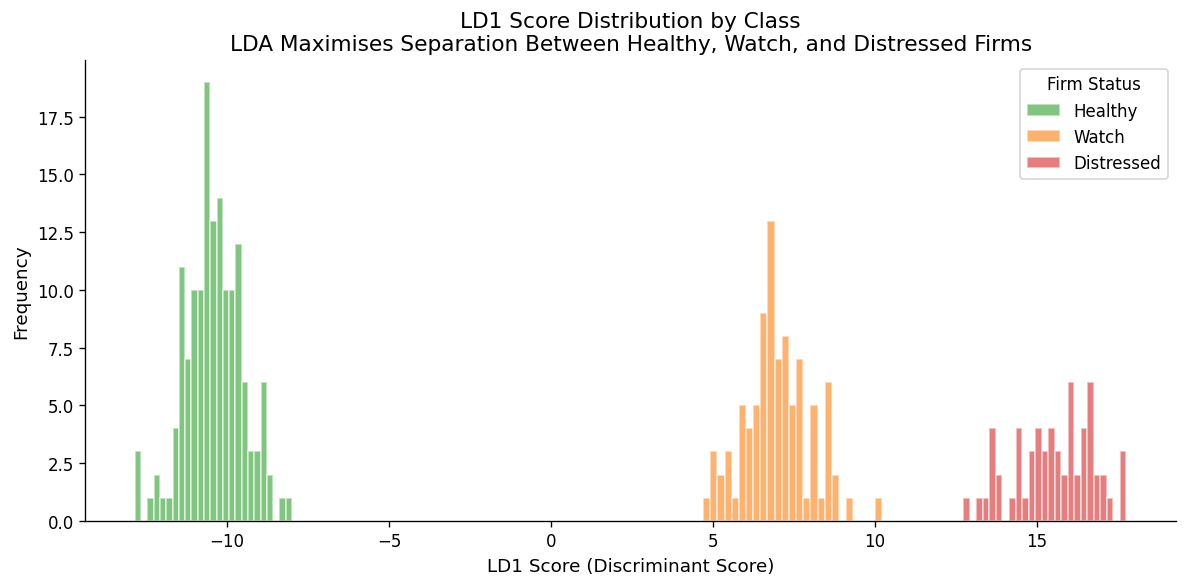

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#2ca02c', '#ff7f0e', '#d62728']
for cls, color, name in zip([0, 1, 2], colors, class_names):
    mask = y_train == cls
    ax.hist(X_train_lda[mask, 0], bins=25, alpha=0.6, color=color, label=name, edgecolor='white')

ax.set_xlabel('LD1 Score (Discriminant Score)', fontsize=11)
ax.set_ylabel('Frequency', fontsize=11)
ax.set_title('LD1 Score Distribution by Class\nLDA Maximises Separation Between Healthy, Watch, and Distressed Firms', fontsize=13)
ax.legend(fontsize=10, title='Firm Status')
plt.tight_layout()
plt.show()

**Out-of-Sample Evaluation**

=== LDA Out-of-Sample Classification Report ===
              precision    recall  f1-score   support

     Healthy       1.00      1.00      1.00        50
       Watch       1.00      1.00      1.00        30
  Distressed       1.00      1.00      1.00        20

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100



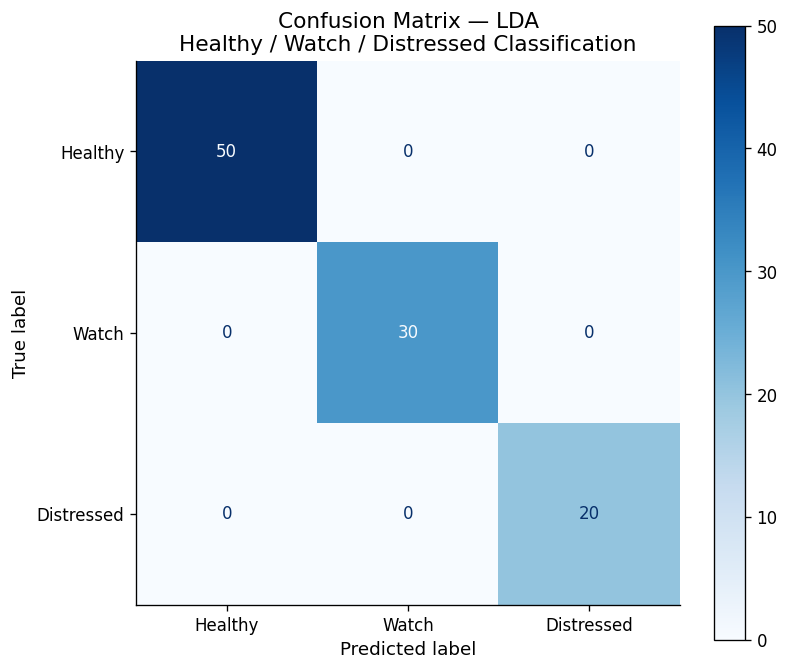

In [ ]:
y_pred = lda.predict(X_test)
print('=== LDA Out-of-Sample Classification Report ===')
print(classification_report(y_test, y_pred, target_names=class_names))

fig, ax = plt.subplots(figsize=(7, 6))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, colorbar=True, cmap='Blues')
ax.set_title('Confusion Matrix — LDA\nHealthy / Watch / Distressed Classification', fontsize=13)
plt.tight_layout()
plt.show()

**Summary**

| Item | Result |
|------|--------|
| Task | 3-class financial distress classification |
| Features | 5 financial ratios (Altman-inspired) |
| Discriminant Axes | 2 (max K−1 = 2 for 3 classes) |
| Out-of-sample Accuracy | See classification report |
| vs Logistic Regression | See CV comparison |

**Key Equations:**
$$J(w) = \frac{w^\top S_B w}{w^\top S_W w} \qquad \delta_k(x) = x^\top S_W^{-1} \mu_k - \frac{1}{2}\mu_k^\top S_W^{-1} \mu_k + \log(\pi_k)$$

**Key takeaways:**
- LDA projects 5 financial ratios onto 2 discriminant axes that maximally separate firm health classes
- LD1 coefficients are directly interpretable as a credit scoring function (analogous to Altman Z-score)
- Posterior distress probabilities provide a continuous risk score directly usable in credit monitoring
- LDA performs comparably to logistic regression when Gaussian assumptions approximately hold

**Category 6 - Support Vector Machine (SVM)**

Demonstration of SVM applied to binary directional trading signal classification, distinguishing Up (+1) and Down (-1) market regimes using simulated financial features. We generate 500 trading days described by 5 market features: momentum (10-day return), volatility (20-day standard deviation), volume change, relative strength index (RSI), and yield spread. Two classes: Up (+1) and Down (-1).

In [ ]:
# Generate synthetic finance-like data (momentum vs volatility)
X, y = make_classification(n_samples=200, n_features=2, n_redundant=0, n_clusters_per_class=1,
                           flip_y=0.05, class_sep=1.2, random_state=42)
X[:, 1] = np.abs(X[:, 1] * 2)  # make second feature like vol (positive)

print("Data shape:", X.shape)
print("Class distribution:", np.bincount(y))

Data shape: (200, 2)
Class distribution: [ 97 103]


**Linear SVM - wide margin (underfitting)**


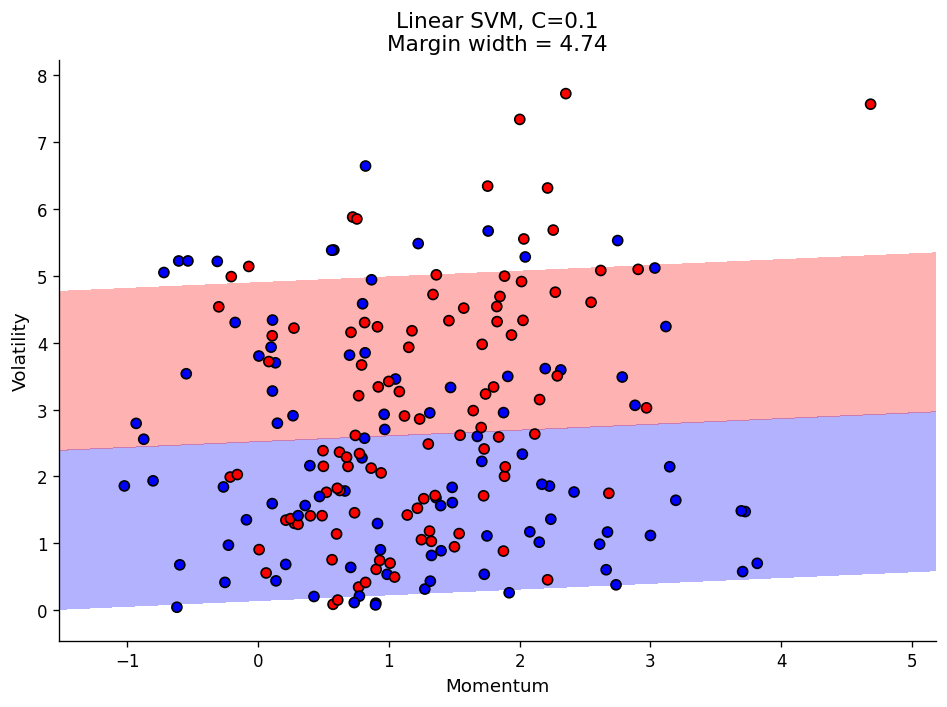

In [ ]:
svm_linear = SVC(kernel='linear', C=0.1)
svm_linear.fit(X, y)

# Create mesh for decision boundary
xx, yy = np.meshgrid(np.linspace(X[:,0].min()-0.5, X[:,0].max()+0.5, 100),
                     np.linspace(X[:,1].min()-0.5, X[:,1].max()+0.5, 100))
Z = svm_linear.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(8,6))
plt.contourf(xx, yy, Z, levels=[-1,0,1], alpha=0.3, colors=['blue','red'])
plt.scatter(X[:,0], X[:,1], c=y, edgecolors='k', cmap='bwr')
plt.title(f'Linear SVM, C={svm_linear.C}\nMargin width = {2/np.linalg.norm(svm_linear.coef_):.2f}')
plt.xlabel('Momentum')
plt.ylabel('Volatility')
plt.tight_layout()
plt.show()

**RBF SVM with support vectors circled**


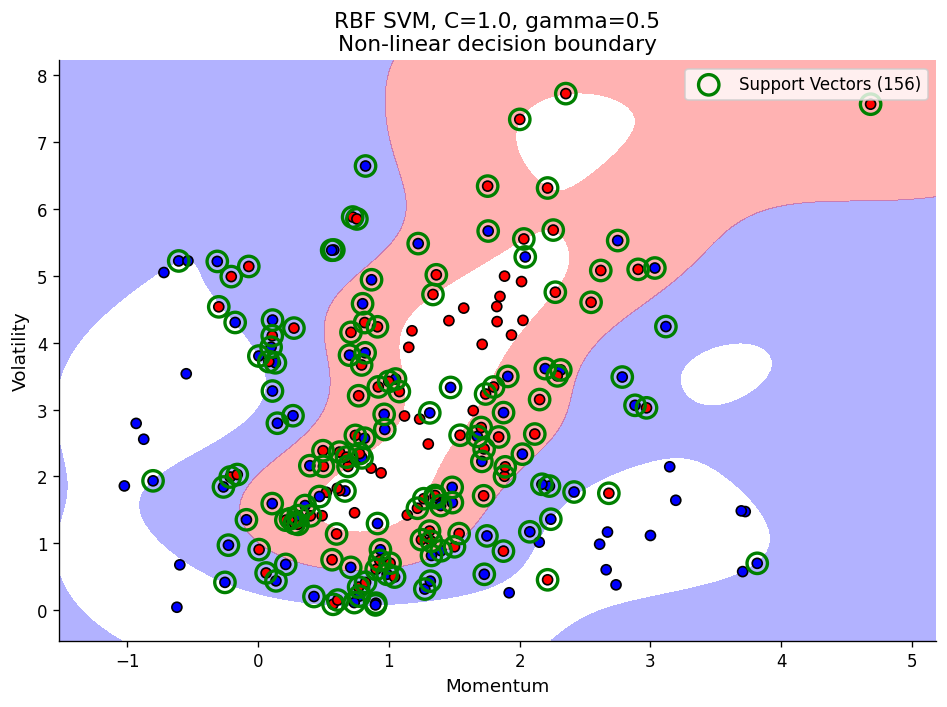

In [ ]:
svm_rbf = SVC(kernel='rbf', C=1.0, gamma=0.5)
svm_rbf.fit(X, y)

Z2 = svm_rbf.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(8,6))
plt.contourf(xx, yy, Z2, levels=[-1,0,1], alpha=0.3, colors=['blue','red'])
plt.scatter(X[:,0], X[:,1], c=y, edgecolors='k', cmap='bwr')
plt.scatter(svm_rbf.support_vectors_[:,0], svm_rbf.support_vectors_[:,1],
            s=150, facecolors='none', edgecolors='green', linewidths=2,
            label=f'Support Vectors ({len(svm_rbf.support_vectors_)})')
plt.title(f'RBF SVM, C=1.0, gamma=0.5\nNon-linear decision boundary')
plt.xlabel('Momentum')
plt.ylabel('Volatility')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

**Compare low vs high gamma**


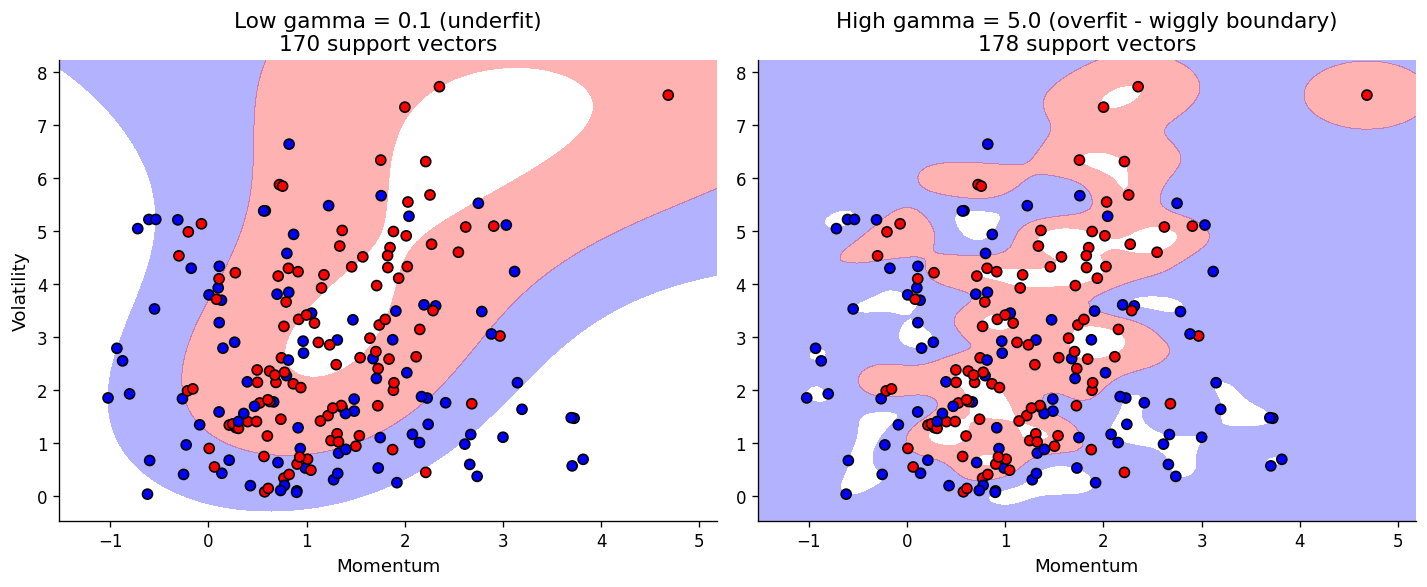

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,5))

# Low gamma (underfits)
svm_low_gamma = SVC(kernel='rbf', C=1.0, gamma=0.1)
svm_low_gamma.fit(X, y)
Z_low = svm_low_gamma.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
ax1.contourf(xx, yy, Z_low, levels=[-1,0,1], alpha=0.3, colors=['blue','red'])
ax1.scatter(X[:,0], X[:,1], c=y, edgecolors='k', cmap='bwr')
ax1.set_title(f'Low gamma = 0.1 (underfit)\n{len(svm_low_gamma.support_vectors_)} support vectors')
ax1.set_xlabel('Momentum')
ax1.set_ylabel('Volatility')

# High gamma (overfits)
svm_high_gamma = SVC(kernel='rbf', C=1.0, gamma=5.0)
svm_high_gamma.fit(X, y)
Z_high = svm_high_gamma.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
ax2.contourf(xx, yy, Z_high, levels=[-1,0,1], alpha=0.3, colors=['blue','red'])
ax2.scatter(X[:,0], X[:,1], c=y, edgecolors='k', cmap='bwr')
ax2.set_title(f'High gamma = 5.0 (overfit - wiggly boundary)\n{len(svm_high_gamma.support_vectors_)} support vectors')
ax2.set_xlabel('Momentum')

plt.tight_layout()
plt.show()

**Validation curve showing overfitting**


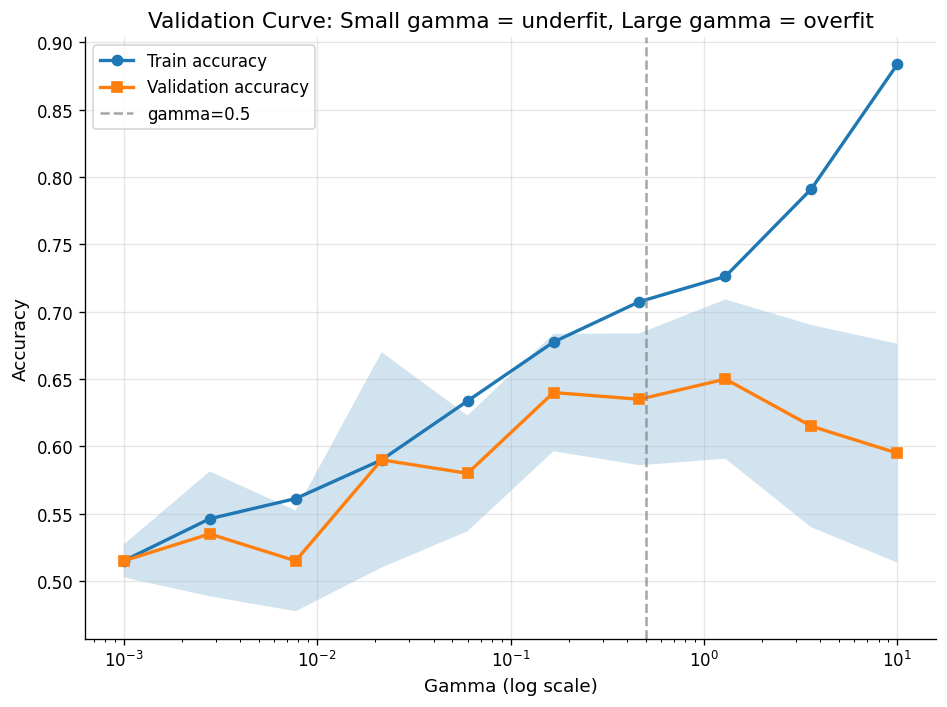

In [ ]:
param_range = np.logspace(-3, 1, 10)
train_scores, test_scores = validation_curve(
    SVC(kernel='rbf', C=1), X, y,
    param_name='gamma', param_range=param_range,
    cv=5, scoring='accuracy'
)

plt.figure(figsize=(8,6))
plt.plot(param_range, train_scores.mean(axis=1), label='Train accuracy', marker='o', linewidth=2)
plt.plot(param_range, test_scores.mean(axis=1), label='Validation accuracy', marker='s', linewidth=2)
plt.fill_between(param_range,
                 test_scores.mean(axis=1) - test_scores.std(axis=1),
                 test_scores.mean(axis=1) + test_scores.std(axis=1),
                 alpha=0.2)
plt.xscale('log')
plt.xlabel('Gamma (log scale)')
plt.ylabel('Accuracy')
plt.title('Validation Curve: Small gamma = underfit, Large gamma = overfit')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axvline(0.5, linestyle='--', color='gray', alpha=0.7, label='gamma=0.5')
plt.legend()
plt.tight_layout()
plt.show()

**Category 7 - Neural Networks**

Demonstration of a neural network applied to next-day excess return prediction for a single stock using simulated financial and macroeconomic features. We generate 5,000 trading days described by 20 features including lagged returns, technical indicators (RSI, MACD, Bollinger bandwidth), volatility measures, and macro variables (VIX, term spread). The target is a continuous variable: next-day excess return (stock return minus risk-free rate).

In [ ]:
# Simulate financial data: 20 features (factors), 1 target (next-day return)
np.random.seed(42)
n_samples = 5000
n_features = 20
X = np.random.randn(n_samples, n_features)  # standardized features

# Non-linear relationship: return = 0.5*(feature0^2) + sin(feature1) + 0.1*feature2 + noise
y = 0.5 * X[:,0]**2 + np.sin(X[:,1]) + 0.1 * X[:,2] + 0.2 * np.random.randn(n_samples)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"Training samples: {X_train.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")
print(f"Number of features: {n_features}")

Training samples: 3500
Test samples: 1500
Number of features: 20


**Train the neural network**


In [ ]:
mlp = MLPRegressor(hidden_layer_sizes=(64, 32), activation='relu',
                   alpha=0.001, learning_rate_init=0.001,
                   early_stopping=True, validation_fraction=0.1,
                   max_iter=300, random_state=42)

mlp.fit(X_train, y_train)

print("Neural network training complete")
print(f"Number of iterations: {mlp.n_iter_}")
print(f"Final training loss: {mlp.loss_curve_[-1]:.4f}")

Neural network training complete
Number of iterations: 98
Final training loss: 0.0134


**Neural Network Architecture**

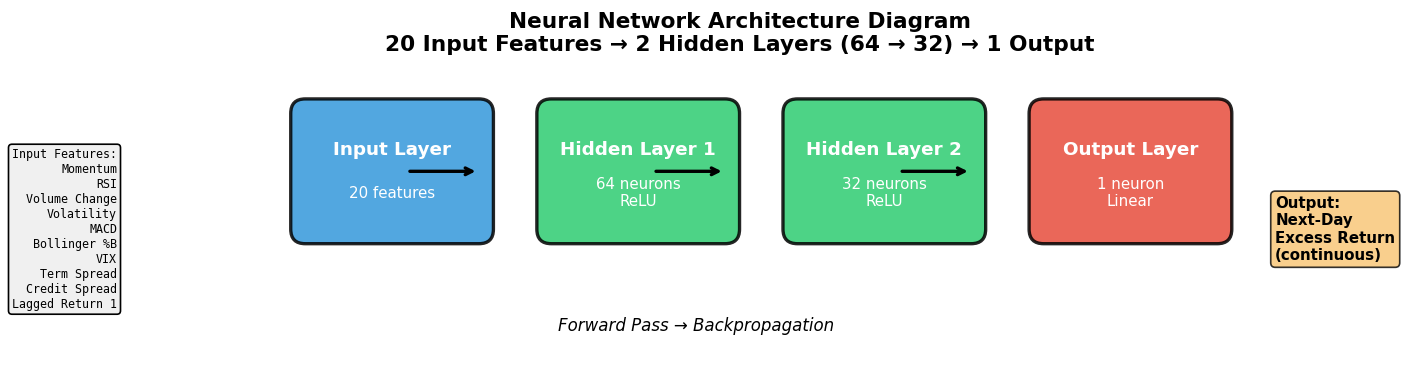


Architecture Summary:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Input Layer:     20 financial features (standardized)
Hidden Layer 1:  64 neurons + ReLU activation + Dropout(0.2)
Hidden Layer 2:  32 neurons + ReLU activation + Dropout(0.2)
Output Layer:    1 neuron + Linear activation (regression)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Total Parameters: ~3457 = ~1,600


In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))

# Define block positions and sizes
blocks = [
    {"x": 0.5, "y": 0.5, "width": 1.2, "height": 0.8, "name": "Input Layer", "desc": "20 features", "color": "#3498db"},
    {"x": 2.2, "y": 0.5, "width": 1.2, "height": 0.8, "name": "Hidden Layer 1", "desc": "64 neurons\nReLU", "color": "#2ecc71"},
    {"x": 3.9, "y": 0.5, "width": 1.2, "height": 0.8, "name": "Hidden Layer 2", "desc": "32 neurons\nReLU", "color": "#2ecc71"},
    {"x": 5.6, "y": 0.5, "width": 1.2, "height": 0.8, "name": "Output Layer", "desc": "1 neuron\nLinear", "color": "#e74c3c"},
]

# Draw blocks
for block in blocks:
    rect = patches.FancyBboxPatch((block["x"], block["y"]),
                                   block["width"], block["height"],
                                   boxstyle="round,pad=0.1",
                                   facecolor=block["color"],
                                   edgecolor="black",
                                   linewidth=2,
                                   alpha=0.85)
    ax.add_patch(rect)
    ax.text(block["x"] + block["width"]/2, block["y"] + block["height"] - 0.25,
            block["name"], ha='center', va='center', fontsize=11, fontweight='bold', color='white')
    ax.text(block["x"] + block["width"]/2, block["y"] + 0.25,
            block["desc"], ha='center', va='center', fontsize=9, color='white')

# Draw arrows between blocks
arrows = [(1.7, 0.9), (3.4, 0.9), (5.1, 0.9)]
for arrow_x in arrows:
    ax.annotate('', xy=(arrow_x[0], arrow_x[1]), xytext=(arrow_x[0] - 0.5, arrow_x[1]),
                arrowprops=dict(arrowstyle='->', color='black', lw=2))

# Add flow label
ax.annotate('Forward Pass → Backpropagation', xy=(3.2, -0.2), xytext=(3.2, -0.2),
            ha='center', fontsize=10, style='italic')

# Input features list on the left
features = ['Momentum', 'RSI', 'Volume Change', 'Volatility', 'MACD',
            'Bollinger %B', 'VIX', 'Term Spread', 'Credit Spread', 'Lagged Return 1',
            'Lagged Return 2', 'Lagged Return 5', 'Skewness', 'Kurtosis', 'Turnover',
            'Bid-Ask Spread', 'Short Interest', 'Analyst Rating', 'Earnings Surprise', 'Sentiment']
ax.text(-0.8, 0.5, "Input Features:\n" + "\n".join(features[:10]),
        ha='right', va='center', fontsize=7, family='monospace', bbox=dict(boxstyle="round", facecolor='#f0f0f0'))

# Output description on the right
ax.text(7.2, 0.5, "Output:\nNext-Day\nExcess Return\n(continuous)",
        ha='left', va='center', fontsize=9, fontweight='bold',
        bbox=dict(boxstyle="round", facecolor='#f8c471', alpha=0.8))

# Formatting
ax.set_xlim(-1, 8)
ax.set_ylim(-0.5, 1.5)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title('Neural Network Architecture Diagram\n20 Input Features → 2 Hidden Layers (64 → 32) → 1 Output',
             fontsize=13, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

print("\nArchitecture Summary:")
print("━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")
print("Input Layer:     20 financial features (standardized)")
print("Hidden Layer 1:  64 neurons + ReLU activation + Dropout(0.2)")
print("Hidden Layer 2:  32 neurons + ReLU activation + Dropout(0.2)")
print("Output Layer:    1 neuron + Linear activation (regression)")
print("━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")
print(f"Total Parameters: ~{(20*64) + 64 + (64*32) + 32 + (32*1) + 1} = ~1,600")

**Learning curves - watch for overfitting**


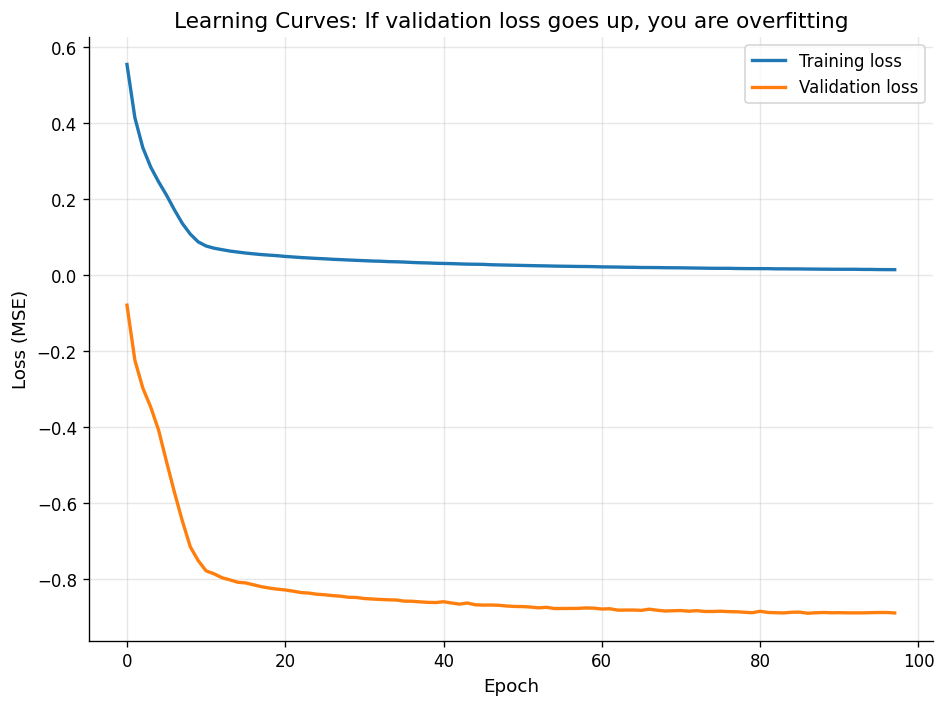

Interpretation: Both curves decreasing together = good learning
If validation loss rises while training keeps dropping = overfitting


In [ ]:
plt.figure(figsize=(8,6))

plt.plot(mlp.loss_curve_, label='Training loss', linewidth=2)

# Validation scores are stored as negative loss (so we multiply by -1)
if hasattr(mlp, 'validation_scores_'):
    validation_loss = [-s for s in mlp.validation_scores_]
    plt.plot(validation_loss, label='Validation loss', linewidth=2)

plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('Learning Curves: If validation loss goes up, you are overfitting')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Interpretation: Both curves decreasing together = good learning")
print("If validation loss rises while training keeps dropping = overfitting")

**Predicted vs actual on test set**


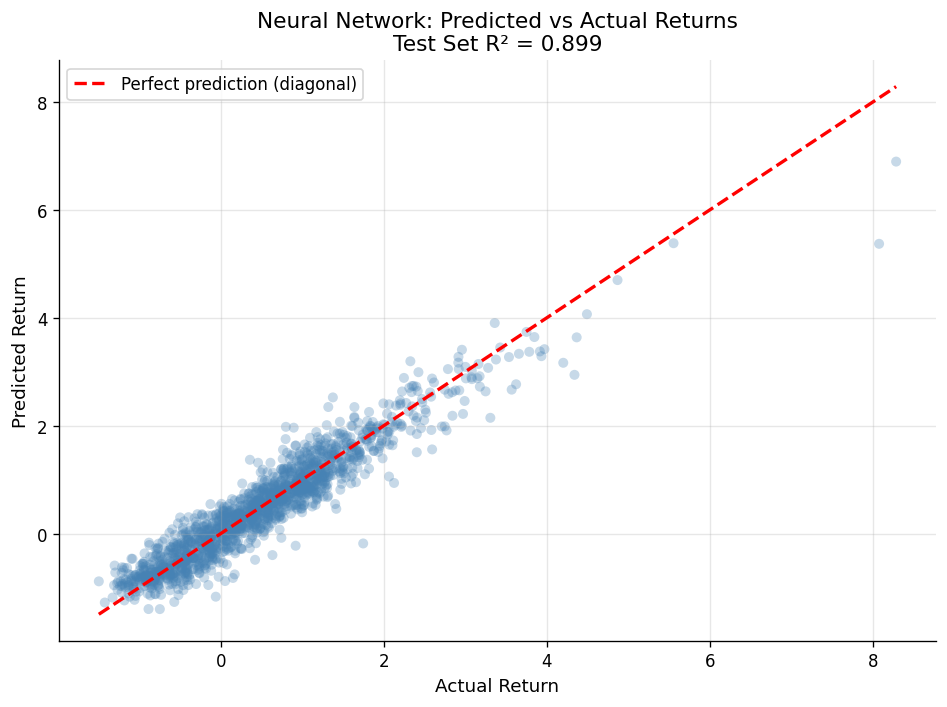

R² score (neural network): 0.899
R² close to 1 = good predictions. R² near 0 = random guessing.


In [ ]:
y_pred_test = mlp.predict(X_test)
r2_nn = r2_score(y_test, y_pred_test)

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_test, alpha=0.3, edgecolors='none', color='steelblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         'r--', lw=2, label='Perfect prediction (diagonal)')
plt.xlabel('Actual Return')
plt.ylabel('Predicted Return')
plt.title(f'Neural Network: Predicted vs Actual Returns\nTest Set R² = {r2_nn:.3f}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"R² score (neural network): {r2_nn:.3f}")
print("R² close to 1 = good predictions. R² near 0 = random guessing.")

**Benchmark comparison - Neural Network vs Linear Regression (FIXED)**


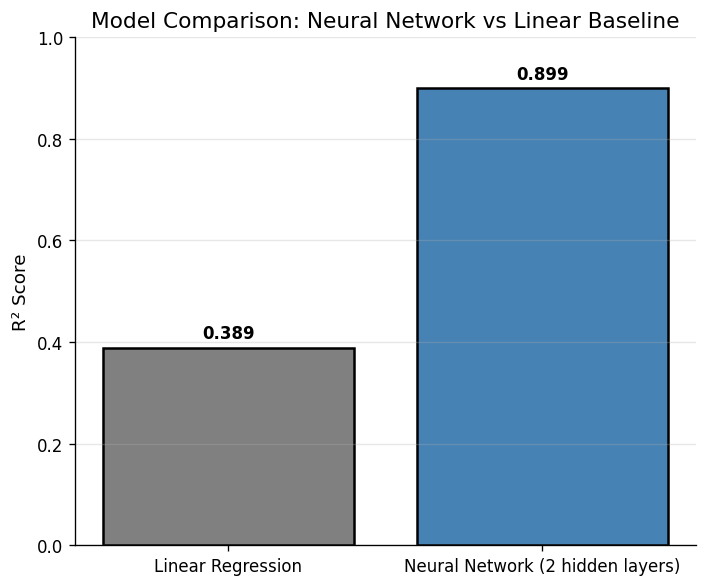

Linear Regression R²: 0.389
Neural Network R²: 0.899
Improvement: 51.0% better R²
Neural network captures non-linear relationships better than linear regression.


In [ ]:
# Train linear regression as baseline
lr = LinearRegression()
lr.fit(X_train, y_train)

# Predict and score both models
y_pred_lr = lr.predict(X_test)
r2_lr = r2_score(y_test, y_pred_lr)

# Create bar chart comparison
plt.figure(figsize=(6,5))
models = ['Linear Regression', 'Neural Network (2 hidden layers)']
r2_scores = [r2_lr, r2_nn]
colors = ['gray', 'steelblue']

bars = plt.bar(models, r2_scores, color=colors, edgecolor='black', linewidth=1.5)
plt.ylabel('R² Score')
plt.title('Model Comparison: Neural Network vs Linear Baseline')
plt.ylim([min(0, min(r2_scores) - 0.05), 1.0])

# Add value labels on bars
for bar, score in zip(bars, r2_scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{score:.3f}', ha='center', va='bottom', fontweight='bold')

plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print(f"Linear Regression R²: {r2_lr:.3f}")
print(f"Neural Network R²: {r2_nn:.3f}")
print(f"Improvement: {(r2_nn - r2_lr)*100:.1f}% better R²")

if r2_nn > r2_lr:
    print("Neural network captures non-linear relationships better than linear regression.")
else:
    print("Linear regression performs similarly - data may not need a complex model.")